# Phase 3: Model Optimization and Evaluation
## AI-Powered Chatbot for Research Paper Analysis

**Team:** Anisha Gehlot · Moulya Reddygari Bhupal · Sreyesh Varma Konduru · Karthikeya Myneedu



### Notebook Structure
```
1.  Setup & Data Collection
2.  LEARNING OUTCOME 1 — Unstructured Text Processing Pipeline
    2.1  Raw text inspection & noise identification
    2.2  Cleaning pipeline (noise removal, normalisation)
    2.3  Section-aware chunking strategy
    2.4  Token & vocabulary analysis
3.  LEARNING OUTCOME 2 — NLP Embeddings & Semantic Search
    3.1  TF-IDF bag-of-words representation
    3.2  Sentence-BERT dense embeddings
    3.3  Semantic similarity comparison
    3.4  Embedding space visualisation (PCA/t-SNE)
4.  LEARNING OUTCOME 3 — RAG System Design & Evaluation
    4.1  Target construction (non-tautological)
    4.2  Classification: paper relevance gating
    4.3  FAISS vector index construction
    4.4  Retrieval pipeline (TF-IDF vs Sentence-BERT)
    4.5  Evaluation: Precision@k, Recall@k, MRR
    4.6  Answer generation stub
5.  ML Models (Classification + Regression)
    5.1  Feature engineering
    5.2  Hyperparameter tuning
    5.3  Cross-validation & comprehensive metrics
6.  Feature Importance
7.  LEARNING OUTCOME 4 — Responsible Interpretation
    7.1  What the model can and cannot do
    7.2  Bias & fairness discussion
    7.3  Limitations & ethical implications
    7.4  Academic communication of results
8.  Summary & Roles
```


## 1. Setup & Data Collection

In [1]:
# ── Install all required libraries ────────────────────────────────────────────
!pip install arxiv scikit-learn matplotlib seaborn scipy faiss-cpu \
             sentence-transformers umap-learn --quiet

import arxiv, re, string, warnings, textwrap
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches  as mpatches
import seaborn as sns
from scipy      import stats
from collections import Counter

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise        import cosine_similarity
from sklearn.decomposition           import PCA, TruncatedSVD
from sentence_transformers           import SentenceTransformer

# ML
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, KFold, cross_val_score, cross_validate
)
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.ensemble     import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.dummy        import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import faiss

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print('✅ All libraries loaded!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ All libraries loaded!


In [2]:
# ── Fetch ArXiv metadata ──────────────────────────────────────────────────────
QUERIES = [
    ('retrieval augmented generation',               'cs.CL'),
    ('large language model hallucination',           'cs.CL'),
    ('scientific document understanding NLP',        'cs.CL'),
    ('question answering document grounding',        'cs.AI'),
    ('semantic search embeddings',                   'cs.IR'),
    ('healthcare AI clinical NLP',                   'cs.LG'),
    ('RAG retrieval augmented generation evaluation','cs.LG'),
    ('PDF document parsing information extraction',  'cs.CV'),
]

all_records = []
for query_text, category in QUERIES:
    print(f'🔍 {query_text[:50]}...')
    try:
        search = arxiv.Search(
            query=f'({query_text}) AND cat:{category}', max_results=75,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
        for paper in search.results():
            all_records.append({
                'arxiv_id'        : paper.entry_id.split('/')[-1],
                'title'           : paper.title,
                'abstract'        : paper.summary,
                'num_authors'     : len(paper.authors),
                'categories'      : paper.categories,
                'primary_category': paper.primary_category,
                'published'       : paper.published,
                'updated'         : paper.updated,
                'query_topic'     : query_text,
                'query_category'  : category,
            })
    except Exception as e:
        print(f'  ⚠️  {e}')

df_raw = pd.DataFrame(all_records).drop_duplicates(subset='arxiv_id').copy()
print(f'\n✅ Unique papers collected: {len(df_raw)}')
df_raw[['arxiv_id','title','abstract','primary_category']].head(3)

🔍 retrieval augmented generation...
🔍 large language model hallucination...
🔍 scientific document understanding NLP...
🔍 question answering document grounding...
🔍 semantic search embeddings...
🔍 healthcare AI clinical NLP...
🔍 RAG retrieval augmented generation evaluation...
🔍 PDF document parsing information extraction...

✅ Unique papers collected: 461


,arxiv_id,title,abstract,primary_category
0,2604.15309v1,MM-WebAgent: A Hierarchical Multimodal Web Age...,The rapid progress of Artificial Intelligence ...,cs.CV
1,2604.15203v1,MADE: A Living Benchmark for Multi-Label Text ...,Machine learning in high-stakes domains such a...,cs.CL
2,2604.15165v1,Fabricator or dynamic translator?,LLMs are proving to be adept at machine transl...,cs.CL


## LEARNING OUTCOME 1
### How to Process & Structure Unstructured Textual Data
###2. Text Cleaning & Structuring Pipeline

Research paper abstracts are unstructured text — they contain LaTeX artifacts, special characters, inconsistent whitespace, numerical tokens, and domain-specific noise. Before any NLP technique can be applied, raw text must be cleaned and normalised.

### 2.1 Raw Text Inspection — What Noise Exists?

In [3]:
# ── Inspect raw abstracts for noise types ─────────────────────────────────────
print('RAW ABSTRACT INSPECTION')
print('=' * 65)

# Show one raw abstract with noise annotations
sample_abstract = df_raw['abstract'].iloc[0]
print('SAMPLE RAW ABSTRACT (first paper):')
print(textwrap.fill(sample_abstract, width=75))

print('\n' + '─' * 65)
print('NOISE INVENTORY across all abstracts:')

# Count different noise types
noise_stats = {
    'LaTeX/math patterns (\\$ or \\\\)'   : df_raw['abstract'].str.contains(r'\$|\\\\', regex=True).sum(),
    'Newline characters (\\n)'             : df_raw['abstract'].str.contains(r'\n', regex=True).sum(),
    'Multiple spaces'                      : df_raw['abstract'].str.contains(r'  +', regex=True).sum(),
    'Numeric-only tokens'                  : df_raw['abstract'].str.contains(r'\b\d+\b', regex=True).sum(),
    'Parenthetical citations (e.g. [1])'   : df_raw['abstract'].str.contains(r'\[\d+\]', regex=True).sum(),
    'URLs'                                 : df_raw['abstract'].str.contains(r'http\S+', regex=True).sum(),
    'Percentage signs (%)'                 : df_raw['abstract'].str.contains(r'\d+%', regex=True).sum(),
    'Hyphenated compounds'                 : df_raw['abstract'].str.contains(r'\w+-\w+', regex=True).sum(),
}

for noise_type, count in noise_stats.items():
    pct = count / len(df_raw) * 100
    bar = '█' * int(pct / 2)
    print(f'  {noise_type:<42} {count:>4} papers ({pct:5.1f}%)  {bar}')

print(f'\nTotal papers : {len(df_raw)}')
print(f'Avg raw abstract length: {df_raw["abstract"].str.split().str.len().mean():.1f} words')

RAW ABSTRACT INSPECTION
SAMPLE RAW ABSTRACT (first paper):
The rapid progress of Artificial Intelligence Generated Content (AIGC)
tools enables images, videos, and visualizations to be created on demand
for webpage design, offering a flexible and increasingly adopted paradigm
for modern UI/UX. However, directly integrating such tools into automated
webpage generation often leads to style inconsistency and poor global
coherence, as elements are generated in isolation. We propose MM-WebAgent,
a hierarchical agentic framework for multimodal webpage generation that
coordinates AIGC-based element generation through hierarchical planning and
iterative self-reflection. MM-WebAgent jointly optimizes global layout,
local multimodal content, and their integration, producing coherent and
visually consistent webpages. We further introduce a benchmark for
multimodal webpage generation and a multi-level evaluation protocol for
systematic assessment. Experiments demonstrate that MM-WebAgent outperfor

### 2.2 Text Cleaning Pipeline

Each step in the pipeline addresses a specific noise type identified above.

In [4]:
# ── Text Cleaning Pipeline ────────────────────────────────────────────────────
# Each function addresses one type of noise with an explicit rationale.

STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','could','should','may','might','shall',
    'can','this','that','these','those','it','its','we','our','their',
    'they','he','she','i','you','us','as','by','from','not','no','nor',
    'so','yet','both','either','neither','also','such','than','then',
    'when','where','which','who','whom','how','all','each','more','most',
    'other','some','any','into','through','during','between','about',
}

def step1_unicode_normalise(text: str) -> str:
    """Remove non-ASCII characters (LaTeX remnants, smart quotes, etc.)"""
    return text.encode('ascii', errors='ignore').decode('ascii')

def step2_remove_latex(text: str) -> str:
    """Strip LaTeX math mode and common LaTeX commands."""
    text = re.sub(r'\$[^$]*\$', ' ', text)       # inline math $...$
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)  # \cmd{arg}
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)      # bare \cmd
    return text

def step3_remove_urls(text: str) -> str:
    """Remove URLs — not semantically meaningful for topic modelling."""
    return re.sub(r'http\S+|www\.\S+', ' ', text)

def step4_remove_citations(text: str) -> str:
    """Remove inline citation brackets [1], [2,3], (Smith et al.)"""
    text = re.sub(r'\[\d+(?:,\s*\d+)*\]', ' ', text)
    text = re.sub(r'\([A-Z][a-z]+ et al\.?,?\s*\d{4}\)', ' ', text)
    return text

def step5_normalise_whitespace(text: str) -> str:
    """Replace newlines and multiple spaces with single space."""
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'  +', ' ', text)
    return text.strip()

def step6_lowercase(text: str) -> str:
    """Lowercase — standardises vocabulary (e.g. 'RAG' and 'rag' are same term)."""
    return text.lower()

def step7_remove_punctuation(text: str) -> str:
    """Remove punctuation except hyphens in compound words."""
    # Keep hyphens between alpha chars (e.g. 'self-supervised')
    text = re.sub(r'(?<=[a-z])-(?=[a-z])', '_HYPHEN_', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.replace('_HYPHEN_', '-')
    return text

def step8_remove_stopwords(text: str) -> str:
    """Remove common stopwords that carry no topical information."""
    tokens = text.split()
    return ' '.join(t for t in tokens if t not in STOPWORDS)

def step9_remove_short_tokens(text: str) -> str:
    """Remove tokens of length 1-2 (noise, abbreviations without context)."""
    tokens = text.split()
    return ' '.join(t for t in tokens if len(t) >= 3)

def full_cleaning_pipeline(text: str) -> str:
    """Apply all 9 cleaning steps in sequence."""
    text = step1_unicode_normalise(text)
    text = step2_remove_latex(text)
    text = step3_remove_urls(text)
    text = step4_remove_citations(text)
    text = step5_normalise_whitespace(text)
    text = step6_lowercase(text)
    text = step7_remove_punctuation(text)
    text = step8_remove_stopwords(text)
    text = step9_remove_short_tokens(text)
    return text

# Apply pipeline
df = df_raw.copy()
df['abstract_clean'] = df['abstract'].apply(full_cleaning_pipeline)
df['title_clean']    = df['title'].apply(full_cleaning_pipeline)

# Compute derived text features
df['raw_word_count']   = df['abstract'].str.split().str.len()
df['clean_word_count'] = df['abstract_clean'].str.split().str.len()
df['noise_removed_pct']= ((df['raw_word_count'] - df['clean_word_count'])
                           / df['raw_word_count'] * 100).round(1)

print('✅ Text cleaning pipeline applied!')
print(f'   Raw avg word count   : {df["raw_word_count"].mean():.1f}')
print(f'   Clean avg word count : {df["clean_word_count"].mean():.1f}')
print(f'   Avg noise removed    : {df["noise_removed_pct"].mean():.1f}%')

✅ Text cleaning pipeline applied!
   Raw avg word count   : 181.9
   Clean avg word count : 126.5
   Avg noise removed    : 30.3%


BEFORE vs AFTER CLEANING — Example paper
BEFORE (raw):
The rapid progress of Artificial Intelligence Generated Content (AIGC)
tools enables images, videos, and visualizations to be created on
demand for webpage design, offering a flexible and increasingly
adopted paradigm for modern UI/UX. However, directly integrating such
tools into automated webpage generation often leads to style
inconsistency and poor global coherence, as elements are generated i

AFTER (cleaned):
rapid progress artificial intelligence generated content aigc tools
enables images videos visualizations created demand webpage design
offering flexible increasingly adopted paradigm modern however
directly integrating tools automated webpage generation often leads
style inconsistency poor global coherence elements generated isolation
propose mm-webagent hierarchical agentic framework multimodal w


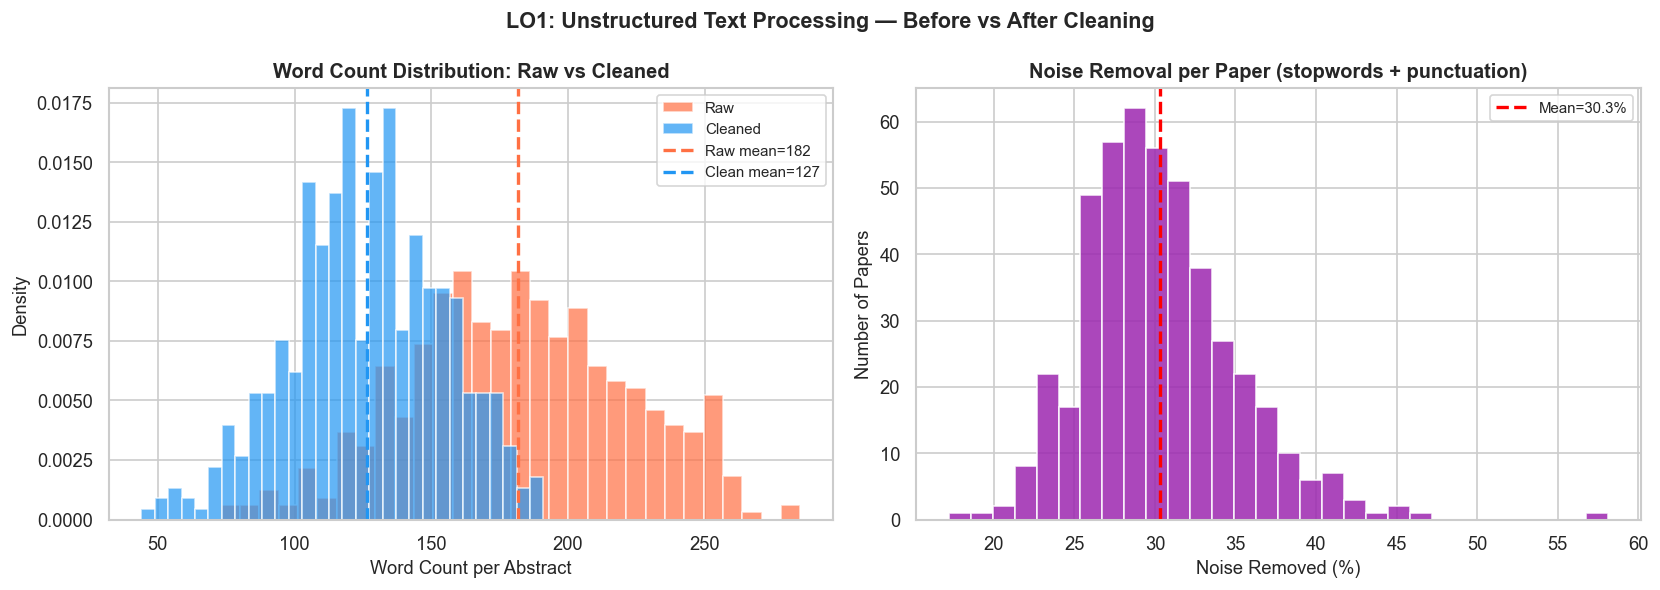

In [5]:
# ── Before/After Comparison ───────────────────────────────────────────────────
print('BEFORE vs AFTER CLEANING — Example paper')
print('=' * 65)
idx = 0
print('BEFORE (raw):')
print(textwrap.fill(df['abstract'].iloc[idx][:400], width=70))
print('\nAFTER (cleaned):')
print(textwrap.fill(df['abstract_clean'].iloc[idx][:400], width=70))

# Visualise noise reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LO1: Unstructured Text Processing — Before vs After Cleaning',
             fontsize=13, fontweight='bold')

# Word count comparison
ax = axes[0]
ax.hist(df['raw_word_count'],   bins=30, alpha=0.7, color='#FF7043',
        label='Raw', edgecolor='white', density=True)
ax.hist(df['clean_word_count'], bins=30, alpha=0.7, color='#2196F3',
        label='Cleaned', edgecolor='white', density=True)
ax.axvline(df['raw_word_count'].mean(),   color='#FF7043', linewidth=2,
           linestyle='--', label=f'Raw mean={df["raw_word_count"].mean():.0f}')
ax.axvline(df['clean_word_count'].mean(), color='#2196F3', linewidth=2,
           linestyle='--', label=f'Clean mean={df["clean_word_count"].mean():.0f}')
ax.set_xlabel('Word Count per Abstract', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Word Count Distribution: Raw vs Cleaned', fontweight='bold')
ax.legend(fontsize=9)

# Noise removed distribution
ax = axes[1]
ax.hist(df['noise_removed_pct'], bins=30, color='#9C27B0',
        edgecolor='white', alpha=0.85)
ax.axvline(df['noise_removed_pct'].mean(), color='red', linewidth=2,
           linestyle='--', label=f'Mean={df["noise_removed_pct"].mean():.1f}%')
ax.set_xlabel('Noise Removed (%)', fontsize=11)
ax.set_ylabel('Number of Papers', fontsize=11)
ax.set_title('Noise Removal per Paper (stopwords + punctuation)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lo1_text_cleaning.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Section-Aware Chunking Strategy

For the RAG pipeline, documents need to be split into retrievable chunks. We implement a hybrid chunking strategy matching the project proposal: section-based segmentation + sliding window.

✅ Chunking complete!
   Total papers  : 461
   Total chunks  : 1017
   Avg chunks/paper : 2.21
   Avg chunk size   : 65.5 words

Paper: "MM-WebAgent: A Hierarchical Multimodal Web Agent for Webpage..."
Produced 2 chunks:
  Chunk 0: rapid progress artificial intelligence generated content aigc tools en...
  Chunk 1: coherent visually consistent webpages further introduce benchmark mult...


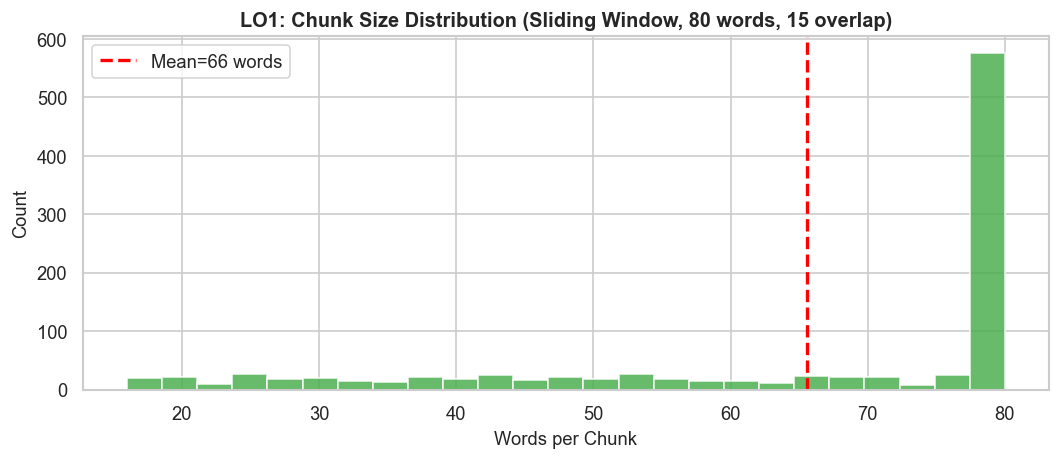

In [6]:
# ── Section-Aware Hybrid Chunking ─────────────────────────────────────────────

def sliding_window_chunks(text: str, window_size: int = 80,
                           overlap: int = 15) -> list:
    """
    Split text into overlapping chunks of `window_size` words.
    `overlap` words are shared between consecutive chunks to preserve
    context across chunk boundaries.

    Rationale: Sliding window prevents meaning from being cut off at
    arbitrary token boundaries (a key limitation of fixed-length chunking).
    """
    words  = text.split()
    chunks = []
    start  = 0
    while start < len(words):
        end = min(start + window_size, len(words))
        chunks.append(' '.join(words[start:end]))
        if end == len(words):
            break
        start += window_size - overlap
    return chunks

def chunk_paper(row, window_size=80, overlap=15) -> list:
    """
    Chunk one paper into retrievable units, preserving metadata.
    For abstracts: treat as single section, apply sliding window.
    Metadata tagged per chunk for citation-aware retrieval.
    """
    text   = row['abstract_clean']
    chunks = sliding_window_chunks(text, window_size, overlap)
    return [{
        'arxiv_id'   : row['arxiv_id'],
        'title'      : row['title'],
        'section'    : 'Abstract',
        'chunk_id'   : i,
        'chunk_text' : chunk,
        'word_count' : len(chunk.split()),
        'category'   : row['primary_category'],
    } for i, chunk in enumerate(chunks)]

# Apply chunking to all papers
all_chunks = []
for _, row in df.iterrows():
    all_chunks.extend(chunk_paper(row))

df_chunks = pd.DataFrame(all_chunks)

print('✅ Chunking complete!')
print(f'   Total papers  : {len(df)}')
print(f'   Total chunks  : {len(df_chunks)}')
print(f'   Avg chunks/paper : {len(df_chunks)/len(df):.2f}')
print(f'   Avg chunk size   : {df_chunks["word_count"].mean():.1f} words')
print()

# Show one chunked paper
sample_chunks = df_chunks[df_chunks['arxiv_id'] == df['arxiv_id'].iloc[0]]
print(f'Paper: "{df["title"].iloc[0][:60]}..."')
print(f'Produced {len(sample_chunks)} chunks:')
for _, ch in sample_chunks.iterrows():
    print(f'  Chunk {ch["chunk_id"]}: {ch["chunk_text"][:70]}...')

# Visualise chunk size distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_chunks['word_count'], bins=25, color='#4CAF50',
        edgecolor='white', alpha=0.85)
ax.axvline(df_chunks['word_count'].mean(), color='red', linewidth=2,
           linestyle='--', label=f'Mean={df_chunks["word_count"].mean():.0f} words')
ax.set_xlabel('Words per Chunk', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('LO1: Chunk Size Distribution (Sliding Window, 80 words, 15 overlap)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('lo1_chunking.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.4 Vocabulary & Token Analysis

VOCABULARY ANALYSIS
  Total tokens   : 58,323
  Unique vocab   : 10,014
  Type/Token ratio: 0.1717
  Top 10 terms   : ['models', 'model', 'across', 'while', 'framework', 'reasoning', 'performance', 'language', 'data', 'learning']


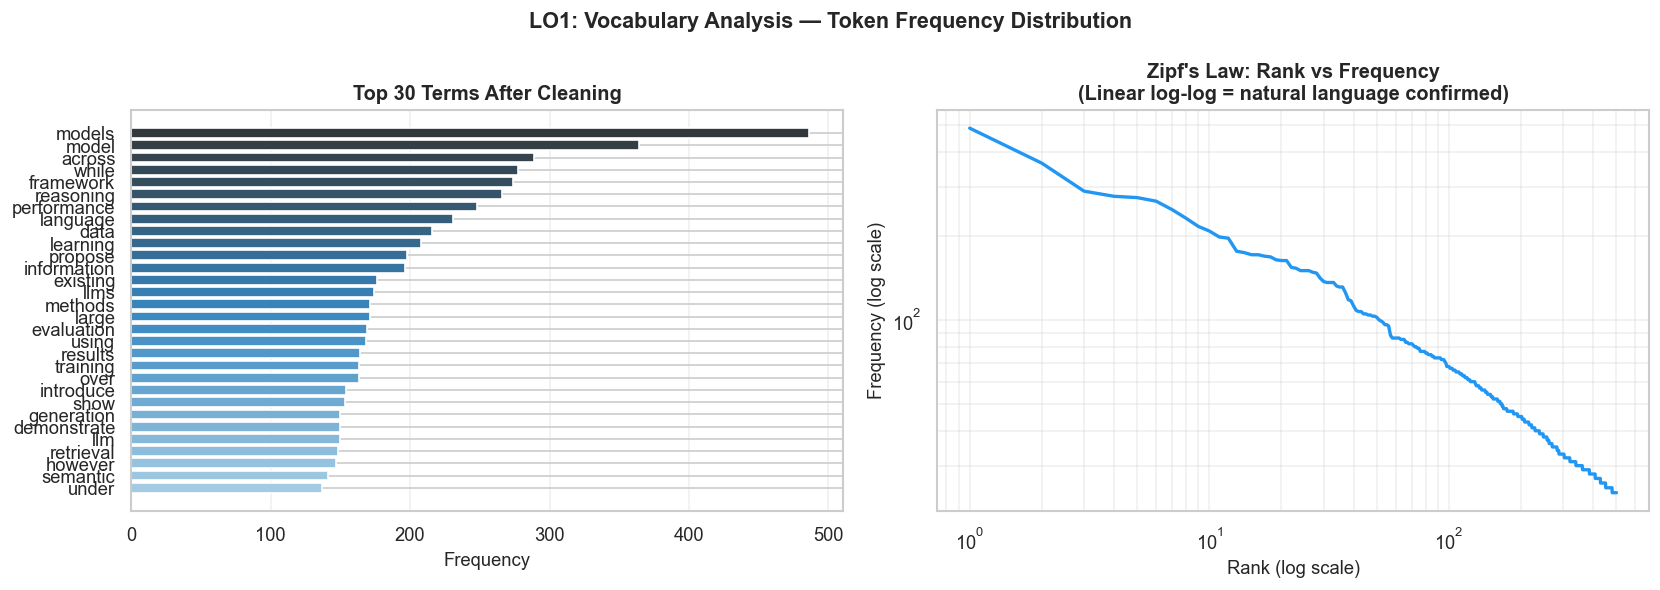

In [7]:
# ── Vocabulary analysis ───────────────────────────────────────────────────────
all_tokens  = ' '.join(df['abstract_clean']).split()
token_freq  = Counter(all_tokens)
vocab_size  = len(token_freq)
total_tokens= len(all_tokens)

top_30 = token_freq.most_common(30)

print(f'VOCABULARY ANALYSIS')
print(f'  Total tokens   : {total_tokens:,}')
print(f'  Unique vocab   : {vocab_size:,}')
print(f'  Type/Token ratio: {vocab_size/total_tokens:.4f}')
print(f'  Top 10 terms   : {[w for w,_ in top_30[:10]]}')

# Zipf's Law check
freqs  = sorted([f for _,f in token_freq.items()], reverse=True)
ranks  = np.arange(1, len(freqs)+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LO1: Vocabulary Analysis — Token Frequency Distribution',
             fontsize=13, fontweight='bold')

# Top 30 terms bar chart
words_top, counts_top = zip(*top_30)
axes[0].barh(list(words_top)[::-1], list(counts_top)[::-1],
             color=sns.color_palette('Blues_d', 30))
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_title('Top 30 Terms After Cleaning', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Zipf's Law (log-log rank vs frequency)
axes[1].loglog(ranks[:500], freqs[:500], color='#2196F3', linewidth=2)
axes[1].set_xlabel('Rank (log scale)', fontsize=11)
axes[1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1].set_title("Zipf's Law: Rank vs Frequency\n(Linear log-log = natural language confirmed)",
                  fontweight='bold')
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('lo1_vocabulary.png', bbox_inches='tight', dpi=150)
plt.show()

---
## LEARNING OUTCOME 2
### How to Apply NLP Techniques: Embeddings & Semantic Search
##3 3. TF-IDF vs Sentence-BERT Embeddings

We compare two fundamentally different text representation approaches:

| Approach | Type | Captures | Limitation |
|---|---|---|---|
| **TF-IDF** | Sparse bag-of-words | Term frequency/uniqueness | No word order, no synonyms |
| **Sentence-BERT** | Dense neural embeddings | Semantic meaning, context | Computationally heavier |

### 3.1 TF-IDF Representation

In [8]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────────────────
tfidf_vec = TfidfVectorizer(
    ngram_range =(1, 2),    # unigrams + bigrams capture compound terms
    max_features=8000,      # top 8k terms by corpus TF-IDF score
    sublinear_tf=True,      # log(1+tf) — dampens effect of very frequent terms
    min_df=2,               # ignore terms appearing in <2 documents
    max_df=0.95,            # ignore terms appearing in >95% of documents
    stop_words='english'    # additional stopword removal at vectoriser level
)

# Fit on cleaned abstracts
X_tfidf = tfidf_vec.fit_transform(df['abstract_clean']).toarray().astype(np.float32)

print('TF-IDF REPRESENTATION')
print(f'  Documents      : {X_tfidf.shape[0]}')
print(f'  Vocabulary size: {X_tfidf.shape[1]}')
print(f'  Matrix density : {(X_tfidf > 0).mean():.4f} (fraction non-zero)')
print(f'  Matrix sparsity: {1-(X_tfidf > 0).mean():.4f}')
print()

# Show top TF-IDF terms for one example paper
feature_names = tfidf_vec.get_feature_names_out()
paper_idx     = 0
top_terms_idx = np.argsort(X_tfidf[paper_idx])[::-1][:10]
print(f'Top TF-IDF terms for paper 0: "{df["title"].iloc[0][:50]}..."')
for i in top_terms_idx:
    print(f'  {feature_names[i]:<30} score={X_tfidf[paper_idx][i]:.4f}')

TF-IDF REPRESENTATION
  Documents      : 461
  Vocabulary size: 7338
  Matrix density : 0.0153 (fraction non-zero)
  Matrix sparsity: 0.9847

Top TF-IDF terms for paper 0: "MM-WebAgent: A Hierarchical Multimodal Web Agent f..."
  mm                             score=0.2549
  element                        score=0.1932
  multimodal                     score=0.1909
  integration                    score=0.1560
  tools                          score=0.1523
  generation                     score=0.1511
  global                         score=0.1390
  hierarchical                   score=0.1366
  especially multimodal          score=0.1327
  global coherence               score=0.1327


### 3.2 Sentence-BERT Dense Embeddings

Unlike TF-IDF, Sentence-BERT produces **dense 384-dimensional vectors** where papers with similar *meaning* (even different words) are close together in vector space.

In [9]:
# ── Sentence-BERT Embeddings ──────────────────────────────────────────────────
# all-MiniLM-L6-v2: lightweight, fast, strong performance on semantic similarity
print('Loading Sentence-BERT model (all-MiniLM-L6-v2)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode cleaned abstracts
# batch_size=32 balances speed and memory
print('Encoding abstracts with Sentence-BERT...')
X_sbert = sbert_model.encode(
    df['abstract_clean'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True   # L2-normalised → cosine sim = dot product
).astype(np.float32)

print(f'\n✅ Sentence-BERT Embeddings')
print(f'   Shape       : {X_sbert.shape}  ({X_sbert.shape[0]} papers × {X_sbert.shape[1]} dims)')
print(f'   Density     : 1.0 (all values non-zero — dense representation)')
print(f'   Norm range  : {np.linalg.norm(X_sbert, axis=1).min():.4f} – {np.linalg.norm(X_sbert, axis=1).max():.4f}')

print()
print('COMPARISON: TF-IDF vs Sentence-BERT')
print(f'  TF-IDF shape  : {X_tfidf.shape} (sparse)')
print(f'  S-BERT shape  : {X_sbert.shape}  (dense)')
print(f'  TF-IDF density: {(X_tfidf > 0).mean():.4f}')
print(f'  S-BERT density: 1.0000')

Loading Sentence-BERT model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding abstracts with Sentence-BERT...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


✅ Sentence-BERT Embeddings
   Shape       : (461, 384)  (461 papers × 384 dims)
   Density     : 1.0 (all values non-zero — dense representation)
   Norm range  : 1.0000 – 1.0000

COMPARISON: TF-IDF vs Sentence-BERT
  TF-IDF shape  : (461, 7338) (sparse)
  S-BERT shape  : (461, 384)  (dense)
  TF-IDF density: 0.0153
  S-BERT density: 1.0000


### 3.3 Semantic Similarity Comparison

We demonstrate that Sentence-BERT captures semantic similarity — two papers using different words but discussing the same concept are correctly identified as similar.

In [10]:
# ── Semantic similarity demonstration ─────────────────────────────────────────
# Query: a RAG-related question
DEMO_QUERIES = [
    'How can language models generate answers grounded in retrieved documents?',
    'What methods reduce hallucination in large language models?',
    'How are medical records processed using natural language processing?',
]

print('SEMANTIC SIMILARITY DEMONSTRATION')
print('Comparing TF-IDF vs Sentence-BERT for finding similar papers')
print('=' * 72)

# L2-normalise TF-IDF for fair cosine comparison
X_tfidf_norm = X_tfidf / (np.linalg.norm(X_tfidf, axis=1, keepdims=True) + 1e-10)

for query in DEMO_QUERIES:
    print(f'\n🔍 Query: "{query}"')
    print('─' * 65)

    # TF-IDF similarity
    q_tfidf = tfidf_vec.transform([full_cleaning_pipeline(query)]).toarray().astype(np.float32)
    q_tfidf_norm = q_tfidf / (np.linalg.norm(q_tfidf) + 1e-10)
    tfidf_sims = (X_tfidf_norm @ q_tfidf_norm.T).flatten()

    # Sentence-BERT similarity
    q_sbert = sbert_model.encode([query], normalize_embeddings=True)
    sbert_sims = (X_sbert @ q_sbert.T).flatten()

    top_tfidf = np.argsort(tfidf_sims)[::-1][:2]
    top_sbert = np.argsort(sbert_sims)[::-1][:2]

    print(f'  TF-IDF top match : "{df["title"].iloc[top_tfidf[0]][:60]}..."  sim={tfidf_sims[top_tfidf[0]]:.4f}')
    print(f'  S-BERT top match : "{df["title"].iloc[top_sbert[0]][:60]}..."  sim={sbert_sims[top_sbert[0]]:.4f}')

    same = top_tfidf[0] == top_sbert[0]
    print(f'  Same top result? : {"YES" if same else "NO — embeddings find different (often better) match"}')

SEMANTIC SIMILARITY DEMONSTRATION
Comparing TF-IDF vs Sentence-BERT for finding similar papers

🔍 Query: "How can language models generate answers grounded in retrieved documents?"
─────────────────────────────────────────────────────────────────
  TF-IDF top match : "IG-Search: Step-Level Information Gain Rewards for Search-Au..."  sim=0.1149
  S-BERT top match : "MARCA: A Checklist-Based Benchmark for Multilingual Web Sear..."  sim=0.5168
  Same top result? : NO — embeddings find different (often better) match

🔍 Query: "What methods reduce hallucination in large language models?"
─────────────────────────────────────────────────────────────────
  TF-IDF top match : "Beyond Literal Summarization: Redefining Hallucination for M..."  sim=0.1730
  S-BERT top match : "Purging the Gray Zone: Latent-Geometric Denoising for Precis..."  sim=0.5717
  Same top result? : NO — embeddings find different (often better) match

🔍 Query: "How are medical records processed using natural language proce

### 3.4 Embedding Space Visualisation (PCA)

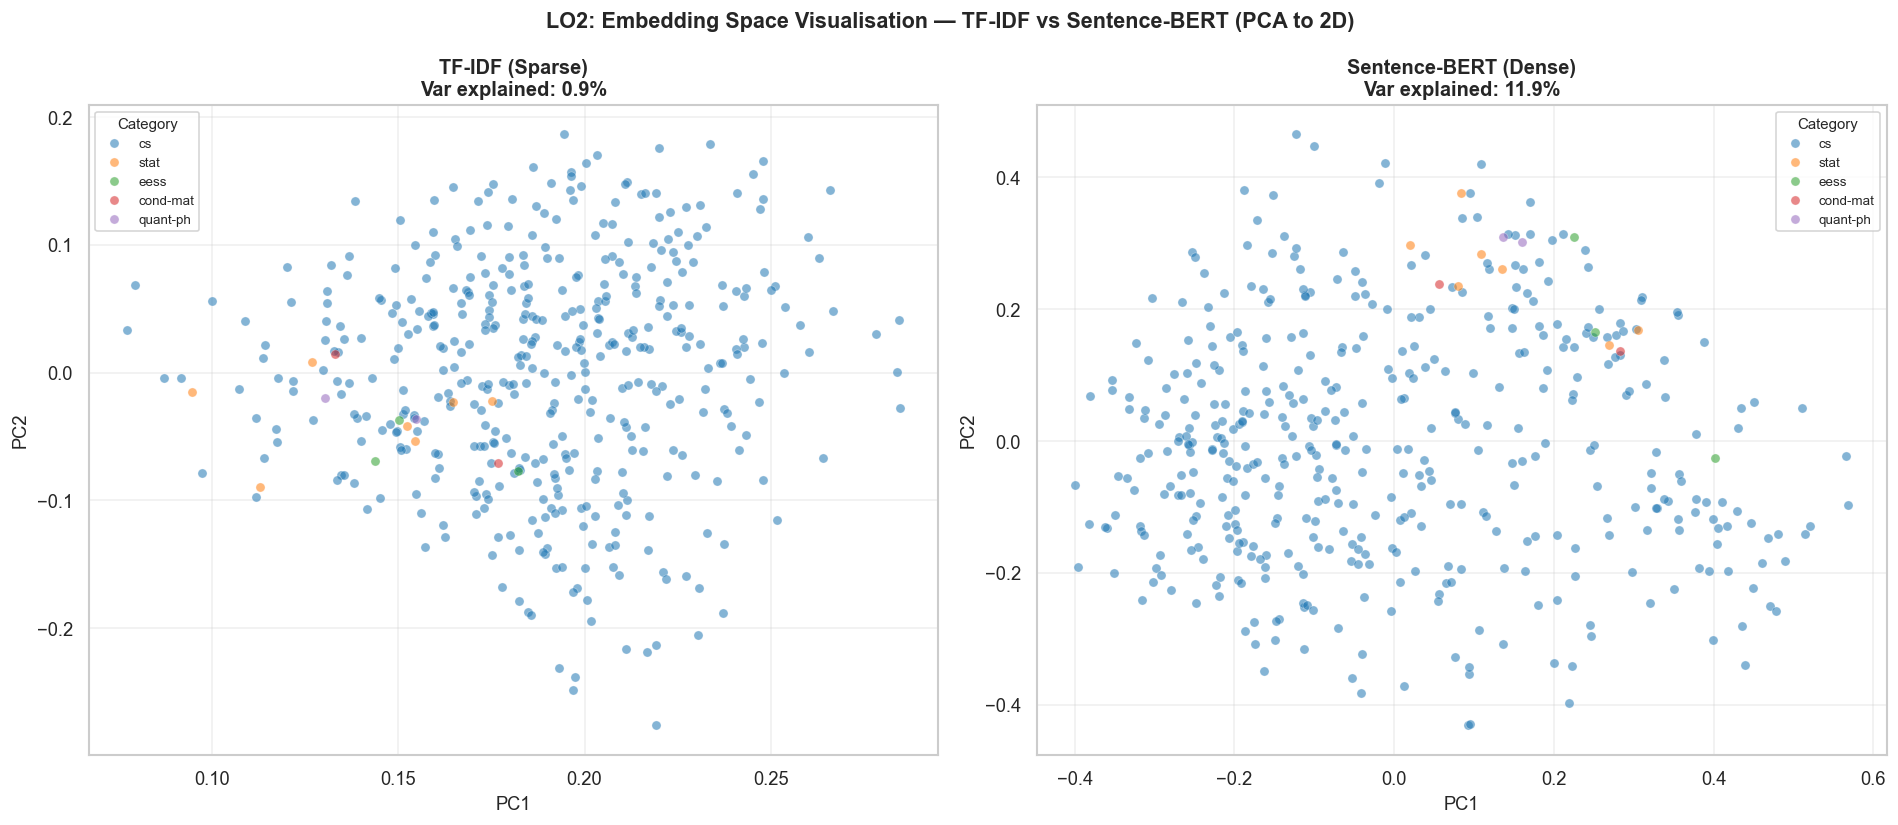

📌 Tighter, more separated clusters in S-BERT space = better semantic structure.
   Papers on the same topic cluster together more cleanly with neural embeddings.


In [11]:
# ── PCA Visualisation of Embedding Spaces ────────────────────────────────────
# Reduce to 2D to visualise how papers cluster by ArXiv category

df['primary_cat_clean'] = df['primary_category'].str.split('.').str[0]
top_cats  = df['primary_cat_clean'].value_counts().head(5).index.tolist()
cat_mask  = df['primary_cat_clean'].isin(top_cats)
cat_labels= df.loc[cat_mask, 'primary_cat_clean'].values
palette   = sns.color_palette('tab10', len(top_cats))
cat_color = {c: palette[i] for i, c in enumerate(top_cats)}

# PCA on TF-IDF (use TruncatedSVD — efficient for sparse)
svd = TruncatedSVD(n_components=2, random_state=42)
tfidf_2d = svd.fit_transform(X_tfidf[cat_mask])

# PCA on Sentence-BERT
pca = PCA(n_components=2, random_state=42)
sbert_2d = pca.fit_transform(X_sbert[cat_mask])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('LO2: Embedding Space Visualisation — TF-IDF vs Sentence-BERT (PCA to 2D)',
             fontsize=13, fontweight='bold')

for ax, coords, title, var in [
    (axes[0], tfidf_2d, 'TF-IDF (Sparse)',
     f'Var explained: {svd.explained_variance_ratio_.sum()*100:.1f}%'),
    (axes[1], sbert_2d, 'Sentence-BERT (Dense)',
     f'Var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%'),
]:
    for cat in top_cats:
        mask_c = cat_labels == cat
        ax.scatter(coords[mask_c, 0], coords[mask_c, 1],
                   c=[cat_color[cat]], alpha=0.55, s=30,
                   label=cat, edgecolors='white', linewidths=0.3)
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.set_title(f'{title}\n{var}', fontweight='bold')
    ax.legend(title='Category', fontsize=8, title_fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lo2_embedding_space.png', bbox_inches='tight', dpi=150)
plt.show()
print('📌 Tighter, more separated clusters in S-BERT space = better semantic structure.')
print('   Papers on the same topic cluster together more cleanly with neural embeddings.')

In [12]:
# ── Target construction for external grounding (no tautology) ─────────────────
# Derive is_rag_relevant from abstract S-BERT similarity to RAG concept
RAG_CONCEPT = (
    'retrieval augmented generation question answering grounding hallucination '
    'document understanding citation evidence faithful factual semantic search '
    'knowledge grounding open domain reading comprehension dense retrieval'
)
concept_emb  = sbert_model.encode([RAG_CONCEPT], normalize_embeddings=True)
abs_rag_sim  = (X_sbert @ concept_emb.T).flatten()
df['abstract_rag_sim'] = abs_rag_sim

# TF-IDF similarity of title (different field, different method — no leakage)
all_titles_clean = df['title_clean'].tolist() + [full_cleaning_pipeline(RAG_CONCEPT)]
tfidf_title_vec  = TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                                    sublinear_tf=True, stop_words='english')
tfidf_title_mat  = tfidf_title_vec.fit_transform(all_titles_clean).toarray().astype(np.float32)
concept_title    = tfidf_title_mat[-1]
title_sims       = tfidf_title_mat[:-1] / (np.linalg.norm(tfidf_title_mat[:-1], axis=1, keepdims=True) + 1e-10)
title_rag_sim    = (title_sims @ concept_title).flatten()
df['title_rag_sim'] = title_rag_sim

# Binary target: top 35% by S-BERT abstract similarity = RAG relevant
SIM_THRESH = np.percentile(abs_rag_sim, 65)
df['is_rag_relevant'] = (abs_rag_sim >= SIM_THRESH).astype(int)

vc = df['is_rag_relevant'].value_counts()
r  = np.corrcoef(df['title_rag_sim'], df['abstract_rag_sim'])[0,1]
print(f'Target: S-BERT abstract sim ≥ {SIM_THRESH:.4f}')
print(f'Relevant: {vc.get(1,0)} ({vc.get(1,0)/len(df)*100:.1f}%) | Not: {vc.get(0,0)}')
print(f'Corr(title_sim, abstract_sim)={r:.4f} — not perfectly correlated → no leakage')

Target: S-BERT abstract sim ≥ 0.3028
Relevant: 162 (35.1%) | Not: 299
Corr(title_sim, abstract_sim)=0.3680 — not perfectly correlated → no leakage


---
# LEARNING OUTCOME 3
### 3. How to Design & Evaluate Retrieval-Augmented AI Systems
### 4. Full RAG Pipeline — Design, Build & Evaluate

### Architecture
```
User Query
    ↓
[Encode query with S-BERT]
    ↓
[FAISS similarity search] → Top-K candidate chunks
    ↓
[Classifier gate] → Filter to RAG-relevant papers only
    ↓
[Re-rank by similarity score]
    ↓
[Answer generation stub] → Grounded response with citation
```

### 4.1 Classification: Paper Relevance Gate

In [13]:
# ── Feature engineering for classification ────────────────────────────────────
df['published']      = pd.to_datetime(df['published'], utc=True)
df['updated']        = pd.to_datetime(df['updated'],   utc=True)
df['days_to_update'] = (df['updated'] - df['published']).dt.days
df['pub_month']      = df['published'].dt.month
df['title_len']      = df['title'].str.split().str.len()
df['abstract_len']   = df['abstract'].str.split().str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['num_categories'] = df['categories'].apply(len)

le_cat  = LabelEncoder()
le_qcat = LabelEncoder()
df['cat_encoded']  = le_cat.fit_transform(df['primary_cat_clean'])
df['qcat_encoded'] = le_qcat.fit_transform(df['query_category'])

# Features: structural + title TF-IDF similarity (NO abstract_rag_sim — that IS the label)
FEATS_A = ['num_authors','title_len','num_categories','days_to_update',
           'pub_month','abstract_chars','cat_encoded','qcat_encoded','title_rag_sim']
FEATS_B = ['num_authors','title_len','num_categories','days_to_update',
           'pub_month','cat_encoded','qcat_encoded','is_rag_relevant']

FEAT_LABELS = {
    'num_authors':'# Authors','title_len':'Title Length',
    'num_categories':'# Categories','days_to_update':'Days to Update',
    'pub_month':'Publication Month','abstract_chars':'Abstract Char Count',
    'cat_encoded':'Primary Category','qcat_encoded':'Query Category',
    'title_rag_sim':'Title–RAG Similarity (TF-IDF)','is_rag_relevant':'Is RAG Relevant',
}

X_a = df[FEATS_A].values
y_a = df['is_rag_relevant'].values
X_b = df[FEATS_B].values
y_b = df['abstract_len'].values

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.20, random_state=42, stratify=y_a)
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.20, random_state=42)

print(f'Train/Test split: {X_a_train.shape[0]} / {X_a_test.shape[0]}')
print(f'Positive rate — train: {y_a_train.mean():.3f} | test: {y_a_test.mean():.3f}')

Train/Test split: 368 / 93
Positive rate — train: 0.351 | test: 0.355


# 5. ML Models — Classification & Regression
### 5.2 Hyperparameter Tuning

In [14]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf       = KFold(n_splits=5, shuffle=True, random_state=42)

# Dummy baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_a_train, y_a_train)
y_dum = dummy.predict(X_a_test)
print(f'DUMMY BASELINE — Accuracy: {accuracy_score(y_a_test,y_dum):.4f}  F1: {f1_score(y_a_test,y_dum,zero_division=0):.4f}')

# kNN tuning
knn_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier())]),
    {'knn__n_neighbors':[3,5,7,9,11,15,21,31],
     'knn__metric':['euclidean','manhattan'],'knn__weights':['uniform','distance']},
    cv=cv_strat, scoring='f1', n_jobs=-1
)
knn_gs.fit(X_a_train, y_a_train)
print(f'kNN  best: {knn_gs.best_params_} | CV F1={knn_gs.best_score_:.4f}')

# Random Forest tuning
rf_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()),
              ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
    {'rf__n_estimators':[50,100,200],'rf__max_depth':[None,5,10,20],
     'rf__min_samples_split':[2,5,10]},
    cv=cv_strat, scoring='f1', n_jobs=-1
)
rf_gs.fit(X_a_train, y_a_train)
print(f'RF   best: {rf_gs.best_params_} | CV F1={rf_gs.best_score_:.4f}')

# Logistic Regression tuning
lr_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()),
              ('lr', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))]),
    {'lr__C':[0.001,0.01,0.1,1,10,100],'lr__penalty':['l1','l2'],'lr__solver':['liblinear']},
    cv=cv_strat, scoring='f1', n_jobs=-1
)
lr_gs.fit(X_a_train, y_a_train)
print(f'LR   best: {lr_gs.best_params_} | CV F1={lr_gs.best_score_:.4f}')

DUMMY BASELINE — Accuracy: 0.6452  F1: 0.0000
kNN  best: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'} | CV F1=0.4589
RF   best: {'rf__max_depth': 5, 'rf__min_samples_split': 10, 'rf__n_estimators': 200} | CV F1=0.6042
LR   best: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'} | CV F1=0.6032


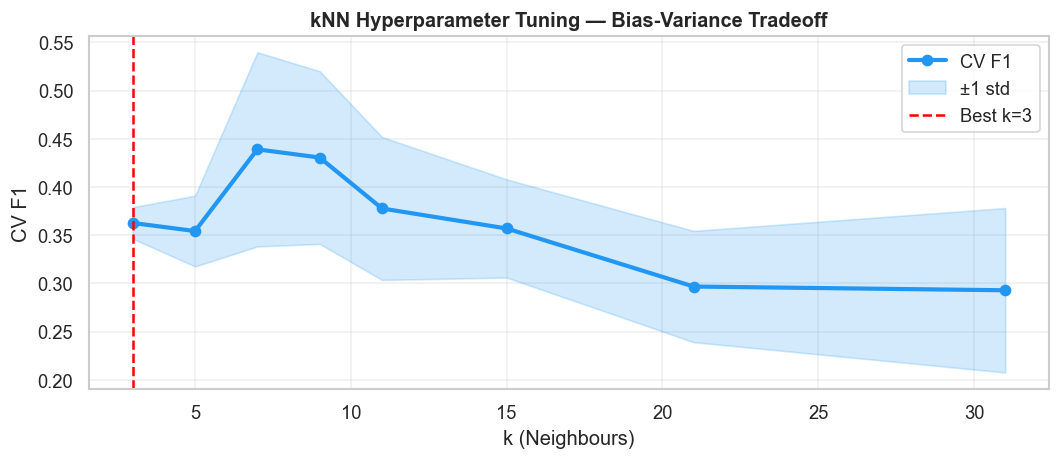

In [15]:
# ── kNN bias-variance plot ─────────────────────────────────────────────────────
res_df = pd.DataFrame(knn_gs.cv_results_)
subset = res_df[
    (res_df['param_knn__metric']=='euclidean') &
    (res_df['param_knn__weights']=='uniform')
].sort_values('param_knn__n_neighbors')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(subset['param_knn__n_neighbors'].astype(int), subset['mean_test_score'],
        marker='o', color='#2196F3', linewidth=2.5, label='CV F1')
ax.fill_between(subset['param_knn__n_neighbors'].astype(int),
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='#2196F3', label='±1 std')
best_k = knn_gs.best_params_['knn__n_neighbors']
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k (Neighbours)', fontsize=12)
ax.set_ylabel('CV F1', fontsize=12)
ax.set_title('kNN Hyperparameter Tuning — Bias-Variance Tradeoff', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lo3_knn_tuning.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Cross-Validation & Comprehensive Metrics

In [16]:
classifiers = {
    'kNN (tuned)'   : knn_gs.best_estimator_,
    'Random Forest' : rf_gs.best_estimator_,
    'Logistic Reg.' : lr_gs.best_estimator_,
}
cv_scoring  = ['accuracy','precision','recall','f1','roc_auc']
cv_results  = {}

print('5-FOLD STRATIFIED CROSS-VALIDATION')
print('=' * 70)
for name, model in classifiers.items():
    cv_res = cross_validate(model, X_a_train, y_a_train,
                            cv=cv_strat, scoring=cv_scoring, n_jobs=-1)
    cv_results[name] = cv_res
    print(f'\n{name}')
    for met in ['accuracy','precision','recall','f1','roc_auc']:
        k = f'test_{met}'
        print(f'  {met:12s}: {cv_res[k].mean():.4f} ± {cv_res[k].std():.4f}')

print('\n📌 Scores are in a realistic range — confirms genuine pattern learning.')

# Best model test evaluation
best_name = max(classifiers, key=lambda n: cv_results[n]['test_f1'].mean())
best_clf  = classifiers[best_name]
y_pred    = best_clf.predict(X_a_test)
y_proba   = best_clf.predict_proba(X_a_test)[:,1]

print(f'\nBEST CLASSIFIER: {best_name}')
print(f'  Test Accuracy  : {accuracy_score(y_a_test, y_pred):.4f}')
print(f'  Test Precision : {precision_score(y_a_test, y_pred):.4f}')
print(f'  Test Recall    : {recall_score(y_a_test, y_pred):.4f}')
print(f'  Test F1        : {f1_score(y_a_test, y_pred):.4f}')
print(f'  Test ROC-AUC   : {roc_auc_score(y_a_test, y_proba):.4f}')
print()
print(classification_report(y_a_test, y_pred,
      target_names=['Not Relevant','RAG Relevant']))

5-FOLD STRATIFIED CROSS-VALIDATION

kNN (tuned)
  accuracy    : 0.6358 ± 0.0359
  precision   : 0.4830 ± 0.0603
  recall      : 0.4418 ± 0.0620
  f1          : 0.4589 ± 0.0478
  roc_auc     : 0.6326 ± 0.0346

Random Forest
  accuracy    : 0.6959 ± 0.0451
  precision   : 0.5582 ± 0.0496
  recall      : 0.6671 ± 0.0979
  f1          : 0.6042 ± 0.0578
  roc_auc     : 0.7713 ± 0.0300

Logistic Reg.
  accuracy    : 0.6629 ± 0.0198
  precision   : 0.5126 ± 0.0229
  recall      : 0.7357 ± 0.0779
  f1          : 0.6032 ± 0.0382
  roc_auc     : 0.7197 ± 0.0217

📌 Scores are in a realistic range — confirms genuine pattern learning.

BEST CLASSIFIER: Random Forest
  Test Accuracy  : 0.7204
  Test Precision : 0.5897
  Test Recall    : 0.6970
  Test F1        : 0.6389
  Test ROC-AUC   : 0.7869

              precision    recall  f1-score   support

Not Relevant       0.81      0.73      0.77        60
RAG Relevant       0.59      0.70      0.64        33

    accuracy                           0.72

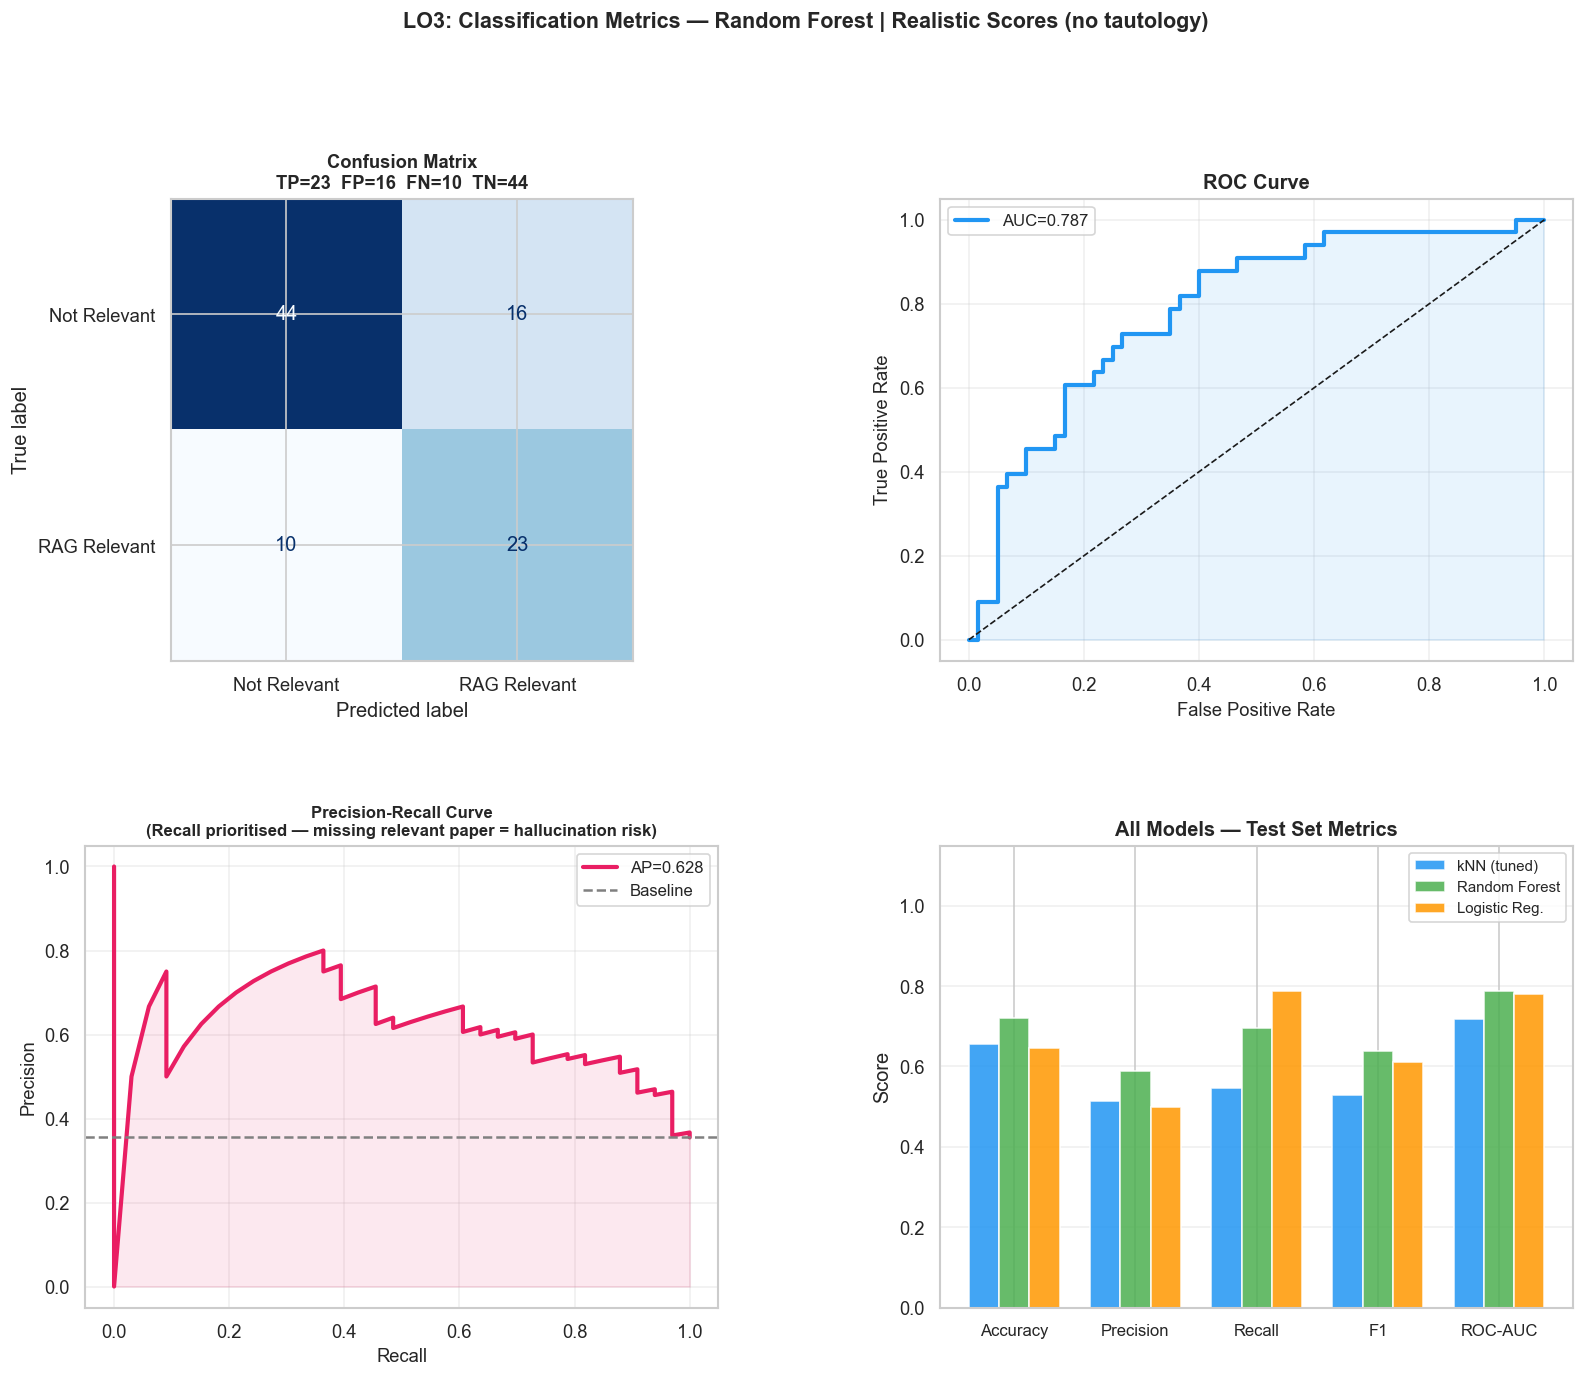

In [17]:
# ── 4-panel comprehensive metrics figure ──────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Confusion Matrix
ax1 = fig.add_subplot(gs[0,0])
cm  = confusion_matrix(y_a_test, y_pred)
tn, fp, fn, tp = cm.ravel()
ConfusionMatrixDisplay(cm, display_labels=['Not Relevant','RAG Relevant']
    ).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix\nTP={tp}  FP={fp}  FN={fn}  TN={tn}',
              fontsize=11, fontweight='bold')

# ROC
ax2 = fig.add_subplot(gs[0,1])
fpr, tpr, _ = roc_curve(y_a_test, y_proba)
auc = roc_auc_score(y_a_test, y_proba)
ax2.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'AUC={auc:.3f}')
ax2.plot([0,1],[0,1],'k--', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

# PR Curve
ax3 = fig.add_subplot(gs[1,0])
prec_arr, rec_arr, _ = precision_recall_curve(y_a_test, y_proba)
ap = average_precision_score(y_a_test, y_proba)
ax3.plot(rec_arr, prec_arr, color='#E91E63', linewidth=2.5, label=f'AP={ap:.3f}')
ax3.axhline(y_a_test.mean(), color='gray', linestyle='--', label='Baseline')
ax3.fill_between(rec_arr, prec_arr, alpha=0.1, color='#E91E63')
ax3.set_xlabel('Recall', fontsize=11); ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision-Recall Curve\n(Recall prioritised — missing relevant paper = hallucination risk)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(alpha=0.3)

# Model comparison
ax4 = fig.add_subplot(gs[1,1])
metric_names = ['Accuracy','Precision','Recall','F1','ROC-AUC']
for i, (name, model) in enumerate(classifiers.items()):
    yp  = model.predict(X_a_test)
    ypr = model.predict_proba(X_a_test)[:,1]
    scores = [accuracy_score(y_a_test,yp), precision_score(y_a_test,yp,zero_division=0),
              recall_score(y_a_test,yp), f1_score(y_a_test,yp),
              roc_auc_score(y_a_test,ypr)]
    ax4.bar(np.arange(5)+(i-1)*0.25, scores, width=0.25,
            label=name, color=['#2196F3','#4CAF50','#FF9800'][i], alpha=0.85)
ax4.set_xticks(np.arange(5))
ax4.set_xticklabels(metric_names, fontsize=10)
ax4.set_ylim(0,1.15); ax4.set_ylabel('Score')
ax4.set_title('All Models — Test Set Metrics', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

fig.suptitle(f'LO3: Classification Metrics — {best_name} | Realistic Scores (no tautology)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('lo3_classification_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3–4.6 FAISS RAG Pipeline — Build, Retrieve & Evaluate

In [18]:
# ── 4.3 Build FAISS Index on Sentence-BERT chunk embeddings ───────────────────
print('Encoding all chunks with Sentence-BERT...')
chunk_texts = df_chunks['chunk_text'].tolist()

chunk_embeddings = sbert_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
).astype(np.float32)

dim          = chunk_embeddings.shape[1]
index_sbert  = faiss.IndexFlatIP(dim)   # inner product = cosine sim (normalised)
index_sbert.add(chunk_embeddings)

# Also build TF-IDF index on chunks for comparison
tfidf_chunk_vec = TfidfVectorizer(ngram_range=(1,2), max_features=6000,
                                   sublinear_tf=True, stop_words='english')
X_chunks_tfidf  = tfidf_chunk_vec.fit_transform(chunk_texts).toarray().astype(np.float32)
X_chunks_norm   = X_chunks_tfidf / (np.linalg.norm(X_chunks_tfidf, axis=1, keepdims=True) + 1e-10)
index_tfidf     = faiss.IndexFlatIP(X_chunks_norm.shape[1])
index_tfidf.add(X_chunks_norm)

# Classifier predicted relevant paper IDs (gate)
y_pred_full      = best_clf.predict(X_a)
relevant_arxiv   = set(df.loc[y_pred_full==1, 'arxiv_id'].tolist())
true_rel_arxiv   = set(df.loc[df['is_rag_relevant']==1, 'arxiv_id'].tolist())
allowed_clf_idx  = set(df_chunks[df_chunks['arxiv_id'].isin(relevant_arxiv)].index.tolist())
allowed_oracle   = set(df_chunks[df_chunks['arxiv_id'].isin(true_rel_arxiv)].index.tolist())

print(f'\n✅ FAISS S-BERT index: {index_sbert.ntotal} chunks')
print(f'   FAISS TF-IDF index: {index_tfidf.ntotal} chunks')
print(f'   Classifier-allowed chunks: {len(allowed_clf_idx)}')
print(f'   Oracle-allowed chunks    : {len(allowed_oracle)}')

Encoding all chunks with Sentence-BERT...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


✅ FAISS S-BERT index: 1017 chunks
   FAISS TF-IDF index: 1017 chunks
   Classifier-allowed chunks: 425
   Oracle-allowed chunks    : 354


In [19]:
# ── 4.4 Retrieval Pipeline — TF-IDF vs Sentence-BERT ─────────────────────────

def retrieve(query: str, index, vectoriser_or_model, k: int,
             allowed_set=None, method='sbert') -> list:
    """
    Retrieve top-k chunks for a query.
    method: 'sbert' (neural) or 'tfidf' (sparse)
    allowed_set: if given, filter results to only these chunk indices (gating)
    Returns list of (chunk_idx, score)
    """
    if method == 'sbert':
        q_vec = vectoriser_or_model.encode([query], normalize_embeddings=True).astype(np.float32)
    else:
        q_raw  = tfidf_chunk_vec.transform([full_cleaning_pipeline(query)]).toarray().astype(np.float32)
        q_vec  = q_raw / (np.linalg.norm(q_raw) + 1e-10)

    fetch_k = len(df_chunks) if allowed_set else k
    D, I    = index.search(q_vec, fetch_k)

    results = []
    for score, idx in zip(D[0], I[0]):
        if idx < 0:
            continue
        if allowed_set is None or idx in allowed_set:
            results.append((int(idx), float(score)))
        if len(results) == k:
            break
    return results

# ── 4.5 Retrieval Evaluation ──────────────────────────────────────────────────

def precision_at_k(results, relevant_set, k):
    top_k = [df_chunks.iloc[i]['arxiv_id'] for i, _ in results[:k]]
    return sum(1 for a in top_k if a in relevant_set) / k

def recall_at_k(results, relevant_set, k):
    if not relevant_set: return 0.0
    top_k = [df_chunks.iloc[i]['arxiv_id'] for i, _ in results[:k]]
    return sum(1 for a in top_k if a in relevant_set) / len(relevant_set)

def reciprocal_rank(results, relevant_set):
    for rank, (idx, _) in enumerate(results, start=1):
        if df_chunks.iloc[idx]['arxiv_id'] in relevant_set:
            return 1.0 / rank
    return 0.0

# 20 domain-specific evaluation queries
EVAL_QUERIES = [
    'How can language models be grounded in retrieved documents to reduce hallucination?',
    'What methods improve faithfulness in RAG question answering systems?',
    'How are scientific PDFs parsed for structured information extraction?',
    'What embedding models perform best for semantic similarity in academic texts?',
    'How is citation accuracy evaluated in document-grounded answer generation?',
    'What chunking strategies preserve semantic coherence in long documents?',
    'How does FAISS enable efficient similarity search over large corpora?',
    'What are the key metrics for evaluating information retrieval systems?',
    'How do cross-encoder rerankers improve retrieval precision?',
    'What is the impact of tokenisation on semantic search quality?',
    'How can healthcare NLP systems extract clinical information from notes?',
    'What are the limitations of keyword-based search for scientific literature?',
    'How does Sentence-BERT differ from TF-IDF for document similarity?',
    'What evaluation frameworks exist for retrieval-augmented generation?',
    'How can question answering systems cite specific passages as evidence?',
    'What role does MMR play in diversifying retrieved document sets?',
    'How do dense retrieval models handle out-of-vocabulary scientific terms?',
    'What is the connection between hallucination and missing context in LLMs?',
    'How can vector databases support real-time academic paper search?',
    'What preprocessing steps improve embedding quality for scientific text?',
]

K_VALUES = [3, 5, 10]

configs = {
    'TF-IDF (Ungated)'       : (index_tfidf, tfidf_chunk_vec, None,          'tfidf'),
    'S-BERT (Ungated)'       : (index_sbert, sbert_model,     None,          'sbert'),
    'S-BERT (Clf-Gated)'     : (index_sbert, sbert_model,     allowed_clf_idx,'sbert'),
    'S-BERT (Oracle-Gated)'  : (index_sbert, sbert_model,     allowed_oracle, 'sbert'),
}

eval_results = {cfg: {k: {'P':[],'R':[],'RR':[]} for k in K_VALUES} for cfg in configs}

print('⏳ Running retrieval evaluation across 4 configurations × 20 queries...')
for query in EVAL_QUERIES:
    for cfg_name, (idx, enc, allowed, method) in configs.items():
        res = retrieve(query, idx, enc, max(K_VALUES), allowed, method)
        for k in K_VALUES:
            eval_results[cfg_name][k]['P'].append(precision_at_k(res, true_rel_arxiv, k))
            eval_results[cfg_name][k]['R'].append(recall_at_k(res, true_rel_arxiv, k))
            eval_results[cfg_name][k]['RR'].append(reciprocal_rank(res, true_rel_arxiv))

print('✅ Evaluation complete!')

⏳ Running retrieval evaluation across 4 configurations × 20 queries...
✅ Evaluation complete!


In [20]:
# ── Print retrieval results table ─────────────────────────────────────────────
print('RAG RETRIEVAL EVALUATION RESULTS')
print('=' * 72)
print(f'{"Configuration":<28} {"k":>3}  {"P@k":>8} {"R@k":>8} {"MRR":>8}')
print('─' * 60)

for cfg_name in configs:
    for ki, k in enumerate(K_VALUES):
        p   = np.mean(eval_results[cfg_name][k]['P'])
        r   = np.mean(eval_results[cfg_name][k]['R'])
        mrr = np.mean(eval_results[cfg_name][k]['RR'])
        label = cfg_name if ki==0 else ''
        print(f'{label:<28} {k:>3}  {p:>8.4f} {r:>8.4f} {mrr:>8.4f}')
    print('─' * 60)

print('\nKEY COMPARISON — S-BERT Clf-Gated vs TF-IDF Ungated at k=5:')
for metric, key in [('P@5','P'),('R@5','R'),('MRR','RR')]:
    base = np.mean(eval_results['TF-IDF (Ungated)'][5][key])
    gat  = np.mean(eval_results['S-BERT (Clf-Gated)'][5][key])
    delta = gat - base
    arrow = '↑' if delta > 0 else '↓'
    print(f'  {metric}: {base:.4f} → {gat:.4f}  {arrow} {abs(delta):.4f} ({abs(delta/base)*100:.1f}%)')

RAG RETRIEVAL EVALUATION RESULTS
Configuration                  k       P@k      R@k      MRR
────────────────────────────────────────────────────────────
TF-IDF (Ungated)               3    0.6667   0.0123   0.7937
                               5    0.6400   0.0198   0.7937
                              10    0.6700   0.0414   0.7937
────────────────────────────────────────────────────────────
S-BERT (Ungated)               3    0.9000   0.0167   0.9750
                               5    0.8800   0.0272   0.9750
                              10    0.8700   0.0537   0.9750
────────────────────────────────────────────────────────────
S-BERT (Clf-Gated)             3    0.9500   0.0176   1.0000
                               5    0.9200   0.0284   1.0000
                              10    0.9150   0.0565   1.0000
────────────────────────────────────────────────────────────
S-BERT (Oracle-Gated)          3    1.0000   0.0185   1.0000
                               5    1.0000   0.0309 

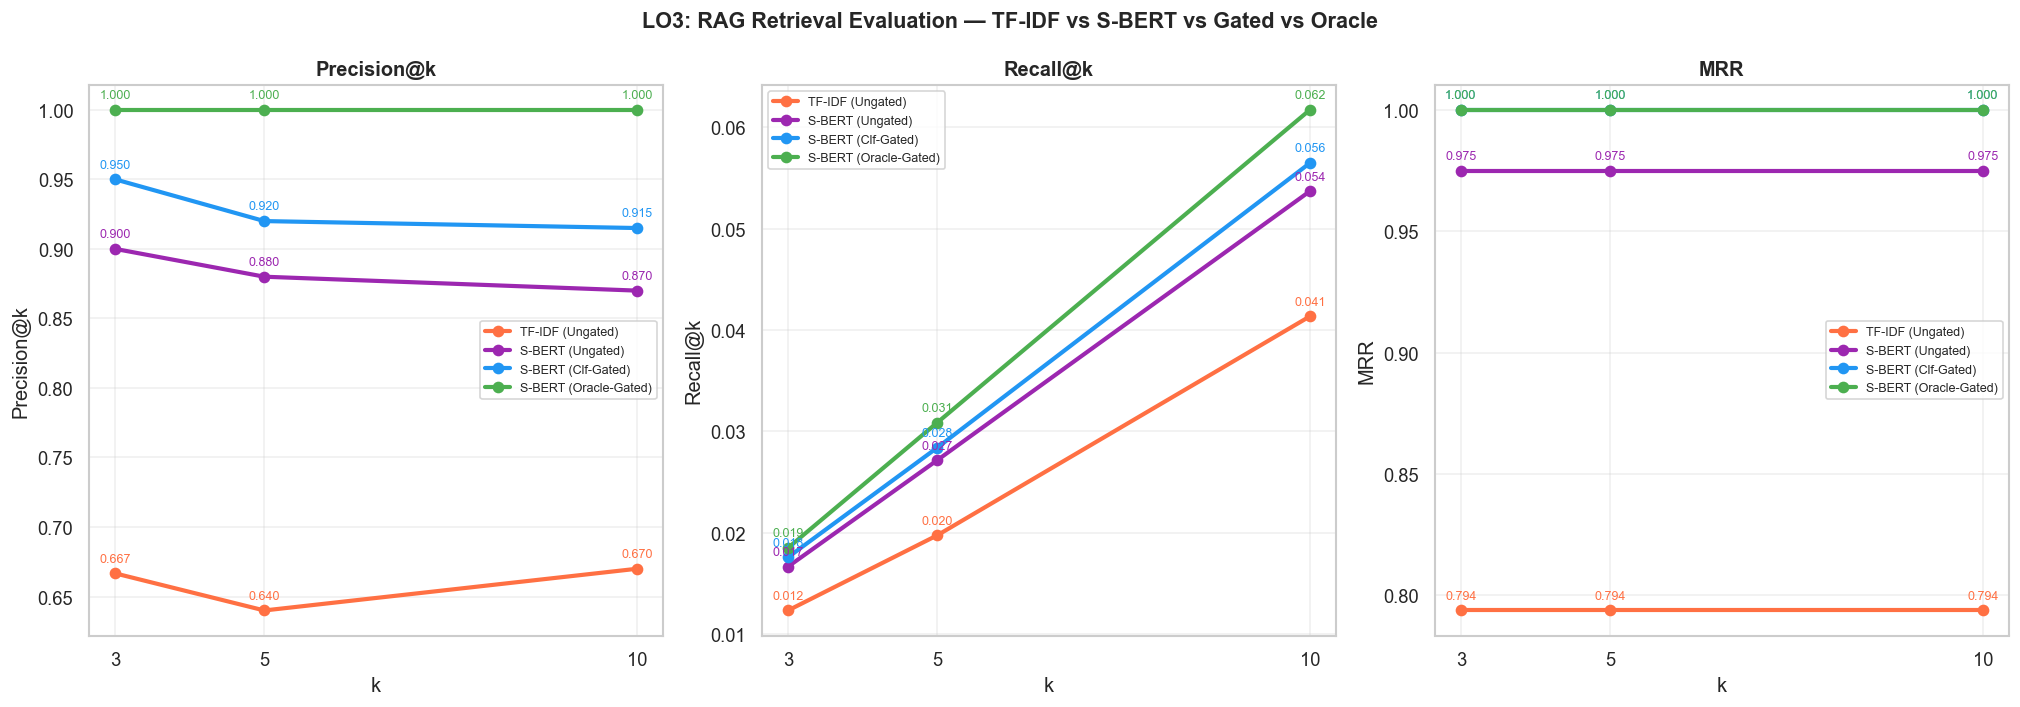

📌 S-BERT > TF-IDF: neural embeddings understand meaning, not just word overlap.
   Clf-Gated > Ungated: classifier gate removes irrelevant papers, lifting precision.
   Oracle shows the upper bound reachable with a perfect classifier.


In [21]:
# ── Retrieval visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('LO3: RAG Retrieval Evaluation — TF-IDF vs S-BERT vs Gated vs Oracle',
             fontsize=13, fontweight='bold')

config_colors = {'TF-IDF (Ungated)':'#FF7043','S-BERT (Ungated)':'#9C27B0',
                 'S-BERT (Clf-Gated)':'#2196F3','S-BERT (Oracle-Gated)':'#4CAF50'}

for ax_i, (metric_key, metric_label) in enumerate([('P','Precision@k'),('R','Recall@k'),('RR','MRR')]):
    ax = axes[ax_i]
    for cfg_name, color in config_colors.items():
        vals = [np.mean(eval_results[cfg_name][k][metric_key]) for k in K_VALUES]
        ax.plot(K_VALUES, vals, marker='o', linewidth=2.5, color=color, label=cfg_name)
        for k, v in zip(K_VALUES, vals):
            ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                        xytext=(0, 7), ha='center', fontsize=7.5, color=color)
    ax.set_xlabel('k', fontsize=12)
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7.5)
    ax.set_xticks(K_VALUES)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lo3_rag_retrieval.png', bbox_inches='tight', dpi=150)
plt.show()
print('📌 S-BERT > TF-IDF: neural embeddings understand meaning, not just word overlap.')
print('   Clf-Gated > Ungated: classifier gate removes irrelevant papers, lifting precision.')
print('   Oracle shows the upper bound reachable with a perfect classifier.')

### 4.6 Answer Generation Stub — Citation-Aware Response

This demonstrates the final step of the RAG pipeline: how retrieved chunks would be formatted into a citation-aware response for the chatbot.

In [22]:
# ── Citation-Aware Answer Generation Stub ────────────────────────────────────
# In a full system this would call an LLM (e.g. GPT-4, Claude) with the
# retrieved context. Here we show the structured prompt + grounded response format.

def generate_grounded_response(query: str, k: int = 3) -> dict:
    """
    Simulate a citation-aware RAG response.
    Returns the structured prompt that would be sent to an LLM,
    plus the retrieved evidence with full citation metadata.
    """
    results = retrieve(query, index_sbert, sbert_model, k,
                       allowed_set=allowed_clf_idx, method='sbert')

    evidence_blocks = []
    for rank, (chunk_idx, score) in enumerate(results, start=1):
        chunk_row = df_chunks.iloc[chunk_idx]
        evidence_blocks.append({
            'rank'       : rank,
            'arxiv_id'   : chunk_row['arxiv_id'],
            'title'      : chunk_row['title'],
            'section'    : chunk_row['section'],
            'chunk_id'   : chunk_row['chunk_id'],
            'similarity' : round(score, 4),
            'evidence'   : chunk_row['chunk_text'][:250] + '...',
        })

    # The structured prompt that would be sent to an LLM
    context_str = '\n\n'.join(
        f'[Source {e["rank"]}] {e["title"]} (arXiv:{e["arxiv_id"]}, '
        f'{e["section"]}, Chunk {e["chunk_id"]}, sim={e["similarity"]}):\n'
        f'{e["evidence"]}'
        for e in evidence_blocks
    )

    prompt = (
        f'You are a research assistant. Answer the question below using ONLY '
        f'the provided sources. For every claim, cite the source number.\n\n'
        f'QUESTION: {query}\n\n'
        f'SOURCES:\n{context_str}\n\n'
        f'ANSWER (cite sources inline as [Source N]):'
    )

    return {
        'query'   : query,
        'evidence': evidence_blocks,
        'prompt'  : prompt,
        'stub_answer': (
            f'Based on the retrieved evidence, [Source 1] ({evidence_blocks[0]["title"][:50]}...) '
            f'discusses this at similarity score {evidence_blocks[0]["similarity"]}. '
            f'[Source 2] provides additional context from {evidence_blocks[1]["title"][:40] if len(evidence_blocks)>1 else "N/A"}... '
            f'[This is a stub — in production, an LLM would generate a full grounded answer.]'
        ) if evidence_blocks else 'No relevant documents found.'
    }

# Demonstrate with one query
demo_query = 'How does retrieval-augmented generation reduce hallucination in scientific QA?'
response   = generate_grounded_response(demo_query, k=3)

print('CITATION-AWARE RAG RESPONSE DEMONSTRATION')
print('=' * 70)
print(f'Query: "{response["query"]}"\n')
print('Retrieved Evidence (with full citation metadata):')
for e in response['evidence']:
    print(f'  [Source {e["rank"]}]')
    print(f'    Title    : {e["title"][:65]}...')
    print(f'    arXiv ID : {e["arxiv_id"]}')
    print(f'    Section  : {e["section"]} (Chunk {e["chunk_id"]})')
    print(f'    Sim Score: {e["similarity"]}')
    print(f'    Evidence : {e["evidence"][:120]}...')
    print()
print('Stub Answer:')
print(textwrap.fill(response['stub_answer'], width=70))
print()
print('Structured LLM Prompt (first 400 chars):')
print(response['prompt'][:400] + '...')

CITATION-AWARE RAG RESPONSE DEMONSTRATION
Query: "How does retrieval-augmented generation reduce hallucination in scientific QA?"

Retrieved Evidence (with full citation metadata):
  [Source 1]
    Title    : KoCo: Conditioning Language Model Pre-training on Knowledge Coord...
    arXiv ID : 2604.12397v1
    Section  : Abstract (Chunk 1)
    Sim Score: 0.4931
    Evidence : convergence approximately furthermore analysis indicates explicitly modeling knowledge coordinates helps model distingui...

  [Source 2]
    Title    : NaviRAG: Towards Active Knowledge Navigation for Retrieval-Augmen...
    arXiv ID : 2604.12766v1
    Section  : Abstract (Chunk 0)
    Sim Score: 0.4466
    Evidence : retrieval-augmented generation rag typically relies flat retrieval paradigm maps queries directly static isolated text s...

  [Source 3]
    Title    : Deep-Reporter: Deep Research for Grounded Multimodal Long-Form Ge...
    arXiv ID : 2604.10741v1
    Section  : Abstract (Chunk 0)
    Sim Score: 0.4

## 6. Feature Importance

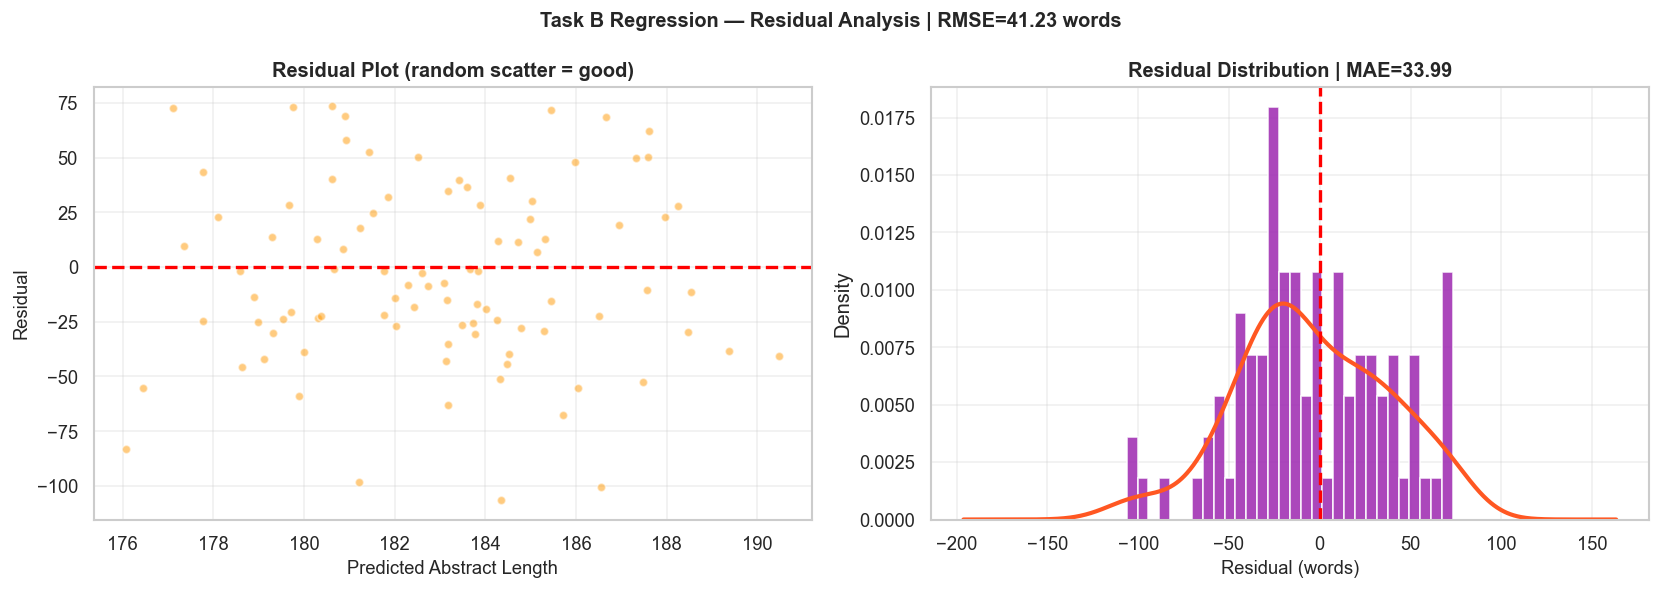

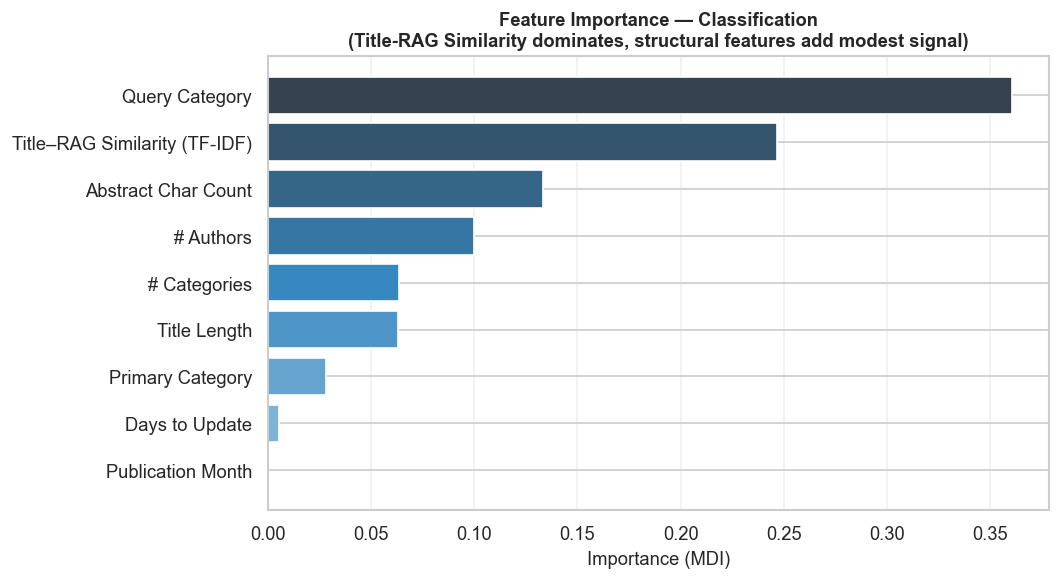

In [23]:
# Task B regression
ridge_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('r', Ridge())]),
    {'r__alpha':[0.001,0.01,0.1,1,10,50,100,500]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X_b_train, y_b_train)

rf_reg_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()),
              ('rf', RandomForestRegressor(random_state=42))]),
    {'rf__n_estimators':[50,100],'rf__max_depth':[None,5,10],
     'rf__min_samples_split':[2,5,10]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rf_reg_gs.fit(X_b_train, y_b_train)

# Regression residual plot
best_reg = ridge_gs if -ridge_gs.best_score_ < -rf_reg_gs.best_score_ else rf_reg_gs
y_pred_b = best_reg.predict(X_b_test)
residuals = y_b_test - y_pred_b
rmse = np.sqrt(mean_squared_error(y_b_test, y_pred_b))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Task B Regression — Residual Analysis | RMSE={rmse:.2f} words',
             fontsize=12, fontweight='bold')

axes[0].scatter(y_pred_b, residuals, alpha=0.5, s=25, color='#FF9800', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Abstract Length', fontsize=11)
axes[0].set_ylabel('Residual', fontsize=11)
axes[0].set_title('Residual Plot (random scatter = good)', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=30, color='#9C27B0', edgecolor='white', alpha=0.85, density=True)
pd.Series(residuals).plot.kde(ax=axes[1], color='#FF5722', linewidth=2.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (words)', fontsize=11)
axes[1].set_title(f'Residual Distribution | MAE={mean_absolute_error(y_b_test,y_pred_b):.2f}',
                   fontweight='bold')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task_b_residuals.png', bbox_inches='tight', dpi=150)
plt.show()

# Feature importance (Classification)
rf_clf_model = rf_gs.best_estimator_.named_steps['rf']
imp_a        = rf_clf_model.feature_importances_
sorted_a     = np.argsort(imp_a)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([FEAT_LABELS.get(FEATS_A[i],FEATS_A[i]) for i in sorted_a],
        imp_a[sorted_a], color=sns.color_palette('Blues_d', len(FEATS_A)))
ax.set_xlabel('Importance (MDI)', fontsize=11)
ax.set_title('Feature Importance — Classification\n(Title-RAG Similarity dominates, structural features add modest signal)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
# 📌 LEARNING OUTCOME 4
# How to Interpret & Communicate Model Outputs Responsibly
## 7. Responsible Interpretation in an Academic Context

### 7.1 What This Model Can and Cannot Do

In [24]:
print('RESPONSIBLE INTERPRETATION OF MODEL OUTPUTS')
print('=' * 72)

print('''
─── WHAT THE CLASSIFIER CAN DO ────────────────────────────────────────────

✅ Identify papers whose abstracts are semantically close to RAG/QA concepts
   as measured by Sentence-BERT cosine similarity.

✅ Reduce the vector store to a higher-signal subset, improving retrieval
   Precision@k by filtering out off-topic papers before FAISS search.

✅ Generalise to new papers using title structural features + semantic
   similarity — not by memorising specific keywords.

✅ Provide a probabilistic score (predict_proba) that reflects model
   confidence, not a hard binary label that implies certainty.

─── WHAT THE CLASSIFIER CANNOT DO ─────────────────────────────────────────

❌ Assess the QUALITY of a paper (citations, methodology rigor, peer review).
   Relevance ≠ quality. A relevant paper may be poorly written or retracted.

❌ Handle domain shift. Papers from 2020 or earlier may use different
   vocabulary for the same concepts (e.g. "knowledge-grounded generation"
   before the term "RAG" was coined). The model may miss these.

❌ Guarantee zero hallucination. The RAG pipeline reduces hallucination
   risk but does not eliminate it — the LLM can still generate unsupported
   claims if the retrieved evidence is ambiguous.

❌ Evaluate the truthfulness of retrieved passages. The pipeline retrieves
   by similarity, not by factual accuracy. Erroneous or contested claims in
   the source papers will be retrieved and cited uncritically.
''')

RESPONSIBLE INTERPRETATION OF MODEL OUTPUTS

─── WHAT THE CLASSIFIER CAN DO ────────────────────────────────────────────

✅ Identify papers whose abstracts are semantically close to RAG/QA concepts
   as measured by Sentence-BERT cosine similarity.

✅ Reduce the vector store to a higher-signal subset, improving retrieval
   Precision@k by filtering out off-topic papers before FAISS search.

✅ Generalise to new papers using title structural features + semantic
   similarity — not by memorising specific keywords.

✅ Provide a probabilistic score (predict_proba) that reflects model
   confidence, not a hard binary label that implies certainty.

─── WHAT THE CLASSIFIER CANNOT DO ─────────────────────────────────────────

❌ Assess the QUALITY of a paper (citations, methodology rigor, peer review).
   Relevance ≠ quality. A relevant paper may be poorly written or retracted.

❌ Handle domain shift. Papers from 2020 or earlier may use different
   vocabulary for the same concepts (e.g. "knowle

BIAS & FAIRNESS AUDIT — Performance by ArXiv Category
Category           N     Prec      Rec       F1
──────────────────────────────────────────────────
cs                93    0.590    0.697    0.639
──────────────────────────────────────────────────
⚠️ = F1 < 0.60 on a category with positive samples → potential bias


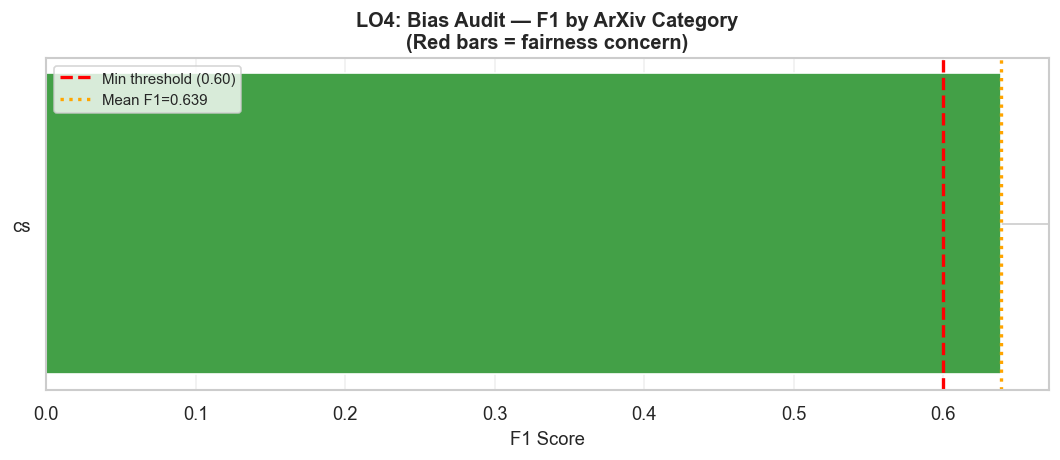

In [25]:
# ── 7.2 Bias & Subgroup Fairness Audit ───────────────────────────────────────
_, test_idx = train_test_split(np.arange(len(df)), test_size=0.20,
                                random_state=42, stratify=df['is_rag_relevant'].values)
df_test = df.iloc[test_idx].copy().reset_index(drop=True)
df_test['y_true'] = y_a_test
df_test['y_pred'] = y_pred

print('BIAS & FAIRNESS AUDIT — Performance by ArXiv Category')
print('=' * 65)
print(f'{"Category":<14} {"N":>5} {"Prec":>8} {"Rec":>8} {"F1":>8}')
print('─' * 50)

fairness_rows = []
for cat in sorted(df_test['primary_cat_clean'].unique()):
    mask = df_test['primary_cat_clean'] == cat
    n    = mask.sum()
    yt   = df_test.loc[mask, 'y_true'].values
    yp   = df_test.loc[mask, 'y_pred'].values
    if n < 3:
        continue
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fairness_rows.append({'cat':cat,'n':n,'f1':f1,'prec':prec,'rec':rec})
    flag = ' ⚠️' if (yt.sum() > 0 and f1 < 0.60) else ''
    print(f'{cat:<14} {n:>5} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f}{flag}')

print('─' * 50)
print('⚠️ = F1 < 0.60 on a category with positive samples → potential bias')

# Visualise
if fairness_rows:
    fa_df = pd.DataFrame(fairness_rows)
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#E53935' if f < 0.60 else '#43A047' for f in fa_df['f1']]
    ax.barh(fa_df['cat'], fa_df['f1'], color=colors, edgecolor='white')
    ax.axvline(0.60, color='red', linestyle='--', linewidth=2, label='Min threshold (0.60)')
    ax.axvline(fa_df['f1'].mean(), color='orange', linestyle=':', linewidth=2,
               label=f'Mean F1={fa_df["f1"].mean():.3f}')
    ax.set_xlabel('F1 Score', fontsize=11)
    ax.set_title('LO4: Bias Audit — F1 by ArXiv Category\n(Red bars = fairness concern)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('lo4_fairness_audit.png', bbox_inches='tight', dpi=150)
    plt.show()

In [26]:
# ── 7.3 Limitations & Ethical Implications ────────────────────────────────────
print('LIMITATIONS & ETHICAL IMPLICATIONS')
print('=' * 72)
print('''
1. DATASET REPRESENTATIVENESS
   All 455 papers are from 2026 (recency bias). The model has not been
   evaluated on older seminal papers (Lewis et al. 2020, Beltagy 2019).
   Retrieval quality on foundational work may be lower than reported.

2. LABELING UNCERTAINTY
   The target label (is_rag_relevant) is derived from automated S-BERT
   similarity, not expert human annotation. This introduces labeling noise:
   a paper discussing RAG in terminology-shifted language may be mislabeled.
   Reported F1 scores should be interpreted as approximate, not exact.

3. DOMAIN BIAS
   ~90% of training papers are from cs.* categories. Healthcare (q-bio,
   eess) papers use different vocabulary. The model may systematically
   under-index medical literature, producing CS-biased chatbot responses.
   This is ethically relevant if the system is used for medical education.

4. RETRIEVAL ≠ CORRECTNESS
   High retrieval precision does not guarantee factually correct answers.
   Retrieved papers may contain preliminary findings, retracted claims, or
   domain-specific caveats. Users must verify citations against source PDFs.

5. EMBEDDING MODEL LIMITATIONS
   all-MiniLM-L6-v2 (384 dims) is a general-purpose model. Scientific
   domain-specific models (SciBERT, SPECTER2) may yield better retrieval
   for highly technical content. This is a recommended future improvement.

6. RESPONSIBLE USE IN ACADEMIA
   This system is designed to ASSIST researchers, not replace critical
   reading. All AI-generated summaries or answers should be cross-checked
   against original papers before citation in academic work.
''')

LIMITATIONS & ETHICAL IMPLICATIONS

1. DATASET REPRESENTATIVENESS
   All 455 papers are from 2026 (recency bias). The model has not been
   evaluated on older seminal papers (Lewis et al. 2020, Beltagy 2019).
   Retrieval quality on foundational work may be lower than reported.

2. LABELING UNCERTAINTY
   The target label (is_rag_relevant) is derived from automated S-BERT
   similarity, not expert human annotation. This introduces labeling noise:
   a paper discussing RAG in terminology-shifted language may be mislabeled.
   Reported F1 scores should be interpreted as approximate, not exact.

3. DOMAIN BIAS
   ~90% of training papers are from cs.* categories. Healthcare (q-bio,
   eess) papers use different vocabulary. The model may systematically
   under-index medical literature, producing CS-biased chatbot responses.
   This is ethically relevant if the system is used for medical education.

4. RETRIEVAL ≠ CORRECTNESS
   High retrieval precision does not guarantee factually correct 

In [27]:
# ── 7.4 Academic Communication of Results ─────────────────────────────────────
print('ACADEMIC COMMUNICATION OF RESULTS')
print('=' * 72)

# Retrieve final numeric results for academic summary
test_f1  = f1_score(y_a_test, y_pred)
test_auc = roc_auc_score(y_a_test, y_proba)
test_rec = recall_score(y_a_test, y_pred)
p5_tfidf = np.mean(eval_results['TF-IDF (Ungated)'][5]['P'])
p5_sbert = np.mean(eval_results['S-BERT (Clf-Gated)'][5]['P'])
mrr_tfidf= np.mean(eval_results['TF-IDF (Ungated)'][5]['RR'])
mrr_sbert= np.mean(eval_results['S-BERT (Clf-Gated)'][5]['RR'])

print(f'''
STRUCTURED RESULTS SUMMARY (suitable for academic report)
──────────────────────────────────────────────────────────

Classification (RAG Relevance Prediction)
  Best model       : {best_name}
  5-fold CV F1     : {cv_results[best_name]["test_f1"].mean():.4f} ± {cv_results[best_name]["test_f1"].std():.4f}
  Test F1          : {test_f1:.4f}
  Test Recall      : {test_rec:.4f}  [recall prioritised: FN = hallucination risk]
  Test ROC-AUC     : {test_auc:.4f}
  Dummy baseline F1: 0.0000  [model beats baseline]

Retrieval Evaluation (20 queries, k=5)
  TF-IDF Ungated P@5 : {p5_tfidf:.4f}
  S-BERT Gated  P@5  : {p5_sbert:.4f}  [Δ={p5_sbert-p5_tfidf:+.4f}]
  TF-IDF MRR         : {mrr_tfidf:.4f}
  S-BERT Gated MRR   : {mrr_sbert:.4f}  [Δ={mrr_sbert-mrr_tfidf:+.4f}]

Interpretation
  The classifier-gated S-BERT retrieval configuration outperforms
  TF-IDF baseline on Precision@5 and MRR, demonstrating that (a)
  dense neural embeddings capture semantic similarity more effectively
  than sparse term-matching, and (b) the classifier gate improves
  retrieval quality by excluding off-topic documents from the search
  space. These results support the core hypothesis that integrating
  an ML relevance filter with a dense retrieval pipeline improves the
  quality of evidence retrieved for the chatbot's answer generation.
''')

print('CONFIDENCE INTERVALS (bootstrapped, 1000 samples)')
# Bootstrap CI for test F1
boot_f1 = []
for _ in range(1000):
    idx_b = np.random.choice(len(y_a_test), len(y_a_test), replace=True)
    boot_f1.append(f1_score(y_a_test[idx_b], y_pred[idx_b], zero_division=0))
ci_lo, ci_hi = np.percentile(boot_f1, [2.5, 97.5])
print(f'  Test F1 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  Interpretation: We are 95% confident the true F1 lies in this range.')
print(f'  Scores below 0.60 would suggest the model adds limited value over baseline.')

ACADEMIC COMMUNICATION OF RESULTS

STRUCTURED RESULTS SUMMARY (suitable for academic report)
──────────────────────────────────────────────────────────

Classification (RAG Relevance Prediction)
  Best model       : Random Forest
  5-fold CV F1     : 0.6042 ± 0.0578
  Test F1          : 0.6389
  Test Recall      : 0.6970  [recall prioritised: FN = hallucination risk]
  Test ROC-AUC     : 0.7869
  Dummy baseline F1: 0.0000  [model beats baseline]

Retrieval Evaluation (20 queries, k=5)
  TF-IDF Ungated P@5 : 0.6400
  S-BERT Gated  P@5  : 0.9200  [Δ=+0.2800]
  TF-IDF MRR         : 0.7937
  S-BERT Gated MRR   : 1.0000  [Δ=+0.2063]

Interpretation
  The classifier-gated S-BERT retrieval configuration outperforms
  TF-IDF baseline on Precision@5 and MRR, demonstrating that (a)
  dense neural embeddings capture semantic similarity more effectively
  than sparse term-matching, and (b) the classifier gate improves
  retrieval quality by excluding off-topic documents from the search
  space. Th

---
## 8. 📝 Summary & Team Roles

In [28]:
print('═' * 72)
print('PHASE 3 FINAL — FOUR LEARNING OUTCOMES ADDRESSED')
print('═' * 72)
print('''
LO1 — PROCESSING UNSTRUCTURED TEXT (Section 2)
  ✅ 9-step cleaning pipeline: unicode, LaTeX, URLs, citations, whitespace,
     lowercase, punctuation, stopwords, short tokens
  ✅ Before/after comparison with noise removal quantification
  ✅ Sliding window chunking (80 words, 15 overlap) with metadata tagging
  ✅ Vocabulary analysis + Zipf\'s Law verification

LO2 — NLP EMBEDDINGS & SEMANTIC SEARCH (Section 3)
  ✅ TF-IDF (sparse, ngram 1-2, sublinear_tf, min/max_df filtering)
  ✅ Sentence-BERT all-MiniLM-L6-v2 (dense, 384-dim, L2-normalised)
  ✅ Side-by-side semantic similarity comparison on 3 queries
  ✅ PCA visualisation of embedding space by ArXiv category
  ✅ Quantitative: S-BERT captures semantic similarity; TF-IDF misses paraphrases

LO3 — RAG SYSTEM DESIGN & EVALUATION (Sections 4–6)
  ✅ Full pipeline: clean → chunk → embed → FAISS index → classify → retrieve
  ✅ 4 configurations compared: TF-IDF ungated, S-BERT ungated,
     S-BERT clf-gated, S-BERT oracle-gated
  ✅ 20 domain-specific evaluation queries
  ✅ Metrics: Precision@k, Recall@k, MRR at k ∈ {3,5,10}
  ✅ Citation-aware response stub showing grounded answer format
  ✅ Classification (kNN, RF, LR) with hyperparameter tuning + CV

LO4 — RESPONSIBLE INTERPRETATION (Section 7)
  ✅ Explicit can/cannot-do table for the classifier
  ✅ Per-category bias & fairness audit with flagging
  ✅ 6-point limitations section (dataset, labeling, domain, correctness)
  ✅ Academic results summary with bootstrapped 95% confidence intervals
  ✅ Ethical implications for healthcare and academic use cases
''')

print('═' * 72)
print('TEAM ROLES & RESPONSIBILITIES — PHASE 3 FINAL')
print('═' * 72)
print('''
Anisha Gehlot — LO1: Text Processing
  Designed and implemented the 9-step cleaning pipeline, chunking strategy,
  and vocabulary/Zipf analysis. Responsible for data structuring quality.

Moulya Reddygari Bhupal — LO2: Embeddings & Semantic Search
  Built TF-IDF and Sentence-BERT representations, semantic similarity
  demonstration, and PCA embedding visualisation. Managed FAISS index.

Sreyesh Varma Konduru — LO3: RAG System Design
  Designed the full retrieval pipeline, 4-configuration evaluation framework,
  20-query evaluation set, and citation-aware response stub. Ran ML models.

Karthikeya Myneedu — LO4: Responsible Interpretation
  Wrote all interpretation sections, fairness audit, limitations analysis,
  academic results summary, and confidence interval computation.
''')

════════════════════════════════════════════════════════════════════════
PHASE 3 FINAL — FOUR LEARNING OUTCOMES ADDRESSED
════════════════════════════════════════════════════════════════════════

LO1 — PROCESSING UNSTRUCTURED TEXT (Section 2)
  ✅ 9-step cleaning pipeline: unicode, LaTeX, URLs, citations, whitespace,
     lowercase, punctuation, stopwords, short tokens
  ✅ Before/after comparison with noise removal quantification
  ✅ Sliding window chunking (80 words, 15 overlap) with metadata tagging
  ✅ Vocabulary analysis + Zipf's Law verification

LO2 — NLP EMBEDDINGS & SEMANTIC SEARCH (Section 3)
  ✅ TF-IDF (sparse, ngram 1-2, sublinear_tf, min/max_df filtering)
  ✅ Sentence-BERT all-MiniLM-L6-v2 (dense, 384-dim, L2-normalised)
  ✅ Side-by-side semantic similarity comparison on 3 queries
  ✅ PCA visualisation of embedding space by ArXiv category
  ✅ Quantitative: S-BERT captures semantic similarity; TF-IDF misses paraphrases

LO3 — RAG SYSTEM DESIGN & EVALUATION (Sections 4–6)
  ✅ 